In [18]:
# 필요 라이브러리 불러오기 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud 
from PIL import Image 
from collections import Counter
import matplotlib.ticker as mtick

# 스타일 지정
sns.set_theme(style='whitegrid')

plt.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False


# 전처리 
### csv파일 읽어오기
- 사이트 는 값이 1개밖에 없기때문에 불러오지 않음

In [19]:
# csv 읽어오기, df.info(), df.nunique() 찍어봄
df = pd.read_csv(
    "./data/eda-proj-fc-purchase.csv",
    usecols=[
        "거래id",
        "유형",
        "고객id",
        "코스ID",
        "포맷",
        "카테고리",
        "코스(상품) 이름",
        "거래일자",
        "쿠폰이름",
        "판매가격",
        "결제수단",
        "실거래금액",
        "쿠폰할인액",
        "거래금액",
        "환불금액",
    ],
)
df.info()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159328 entries, 0 to 159327
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   거래id       159328 non-null  int64 
 1   유형         159328 non-null  object
 2   고객id       159328 non-null  int64 
 3   코스ID       159328 non-null  int64 
 4   포맷         159328 non-null  object
 5   카테고리       159328 non-null  object
 6   코스(상품) 이름  159328 non-null  object
 7   거래일자       159328 non-null  object
 8   쿠폰이름       159328 non-null  object
 9   판매가격       159328 non-null  object
 10  결제수단       159328 non-null  object
 11  실거래금액      159328 non-null  int64 
 12  쿠폰할인액      159328 non-null  object
 13  거래금액       159328 non-null  object
 14  환불금액       159328 non-null  object
dtypes: int64(4), object(11)
memory usage: 18.2+ MB


거래id         159328
유형                2
고객id          79615
코스ID            407
포맷                2
카테고리             11
코스(상품) 이름       407
거래일자         121645
쿠폰이름           1227
판매가격            625
결제수단              6
실거래금액          3366
쿠폰할인액          1201
거래금액           1606
환불금액           1763
dtype: int64

- df.info()와 df.nunique()에서 확인한 값을 바탕으로 전처리해줌
- 쿠폰할인액, 거래금액, 환불금액을 숫자형 으로 바꾸고 결측치는 0으로 채움
- 판매가격 결측치가 있는 row는 제거하고, 숫자형으로 타입을 바꿔줌

In [20]:
# 전처리: 쿠폰할인액, 거래금액, 환불금액을 숫자형(int)으로 바꾸고 결측치는 0으로 채우기
col_list = ["쿠폰할인액", "거래금액", "환불금액"]
for col_name in col_list:
    df[col_name] = (
        pd.to_numeric(arg=df[col_name], errors="coerce")
        .fillna(0)
        .astype("int64")
    )

In [21]:
# 전처리: 판매가격 결측치 삭제하기
df["판매가격"] = pd.to_numeric(arg=df["판매가격"], errors="coerce").astype("Int64")
df = df.dropna(subset=["판매가격"])
df["판매가격"] = df["판매가격"].astype("int64")


- 고객의 구매수를 쉽게 확인하기위해 컬럼추가 (int)
  - 구매횟수 : p_count (int)
  - 환불횟수 : r_count (int)
   
     
- 시간에 대한 처리를 편하게 하기 위해 시간 컬럼추가 
  - 연월일 : p_date (datetime)
  - 요일 : p_week (월요일, 화요일, ..., 일요일)
  - 시간 : p_time (int)

In [22]:
# 전처리: 고객의 구매수 column 추가 'p_count', 'r_count'
p_mask = df["유형"] == "PAYMENT"
purchase_count = df.loc[p_mask, "고객id"].value_counts()

r_mask = df["유형"] == "REFUND"
refund_count = df.loc[r_mask, "고객id"].value_counts()

df["p_count"] = df.loc[p_mask, "고객id"].apply(lambda x: purchase_count[x])
df["r_count"] = df.loc[r_mask, "고객id"].apply(lambda x: refund_count[x])

df["p_count"] = df["p_count"].fillna(0).astype("int8")
df["r_count"] = df["r_count"].fillna(0).astype("int8")


In [23]:
# 전처리: 시간 컬럼들 추가 하기 p_date, p_week, p_time
df_front = df["거래일자"].apply(
    lambda x: re.split(r"\s[가-힣]", x)[0].replace(" ", "")
)
df_middle = df["거래일자"].apply(lambda x: re.findall(r"([가-힣]+)", x)[0])
df_end = df["거래일자"].apply(
    lambda x: re.split(r"([가-힣]+)", x)[-1].replace(" ", "")
)

df["p_date"] = pd.to_datetime(df_front, format="%Y.%m.%d.")

df["p_week"] = df["p_date"].dt.weekday

df_end = pd.to_datetime(df_end, format="%H:%M:%S").dt.hour
df_middle = df_middle == "오후"
df_end = df_end + df_middle * 12
df["p_time"] = pd.to_numeric(df_end)


In [24]:
# 전처리 : p_week를 요일로 바꾸는 작업을 진행

# 숫자를 요일로 바꾸기 위한 딕셔너리 생성
day_yoyil = {
    0: "월요일",
    1: "화요일",
    2: "수요일",
    3: "목요일",
    4: "금요일",
    5: "토요일",
    6: "일요일",
}

# 'p_week' 칼럼의 값들을 요일로 바꾸고 데이터타입을 문자열(str)로 변경
df["p_week"] = df["p_week"].replace(day_yoyil)


- 판매가격보다 쿠폰할인액이 큰경우
  - -> 잘못됨 (쿠폰할인액이 판매가격보다 클수 없음)
  - -> 쿠폰할인액을 판매금액과 동일하게 맞춰줌
- 위의 값을 '할인금액조정' 이라는 컬럼에 추가해줌 (int)

In [25]:
# 전처리 : '할인금액조정' : 쿠폰할인액 대신 사용할것, 쿠폰이름 특정내용 있는 행 삭제

# 1. 판매가격보다 < 쿠폰할인액이 큰 경우 : 판매가격으로 조정
df["할인금액조정"] = df["쿠폰할인액"]
df.loc[df["쿠폰할인액"] > df["판매가격"], "할인금액조정"] = df["판매가격"]

# 2. drop_txt : 쿠폰이름에 특정 문자 포함시 행 삭제 ['강사', '내부직원', '참고용', '검수', '결제테스트','테스트쿠폰']
drop_txt = ["강사", "내부직원", "참고용", "검수", "결제테스트", "테스트쿠폰"]
df = df[~df["쿠폰이름"].str.contains("|".join(drop_txt))]

# 3. cp_tag : 쿠폰이름에서 [] 사이에 있는 텍스트를 tag로 지정하는 열 추가
df["cp_tag"] = df[df["쿠폰이름"] != "-"]["쿠폰이름"].str.extract("\[(.*?)\]")


In [26]:
# 전처리: coupon 컬럼 추가 True, False, p_month 추가
df["coupon"] = df["쿠폰할인액"] >= 1

df["p_month"] = df["p_date"].dt.weekday
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 157478 entries, 0 to 159327
Data columns (total 24 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   거래id       157478 non-null  int64         
 1   유형         157478 non-null  object        
 2   고객id       157478 non-null  int64         
 3   코스ID       157478 non-null  int64         
 4   포맷         157478 non-null  object        
 5   카테고리       157478 non-null  object        
 6   코스(상품) 이름  157478 non-null  object        
 7   거래일자       157478 non-null  object        
 8   쿠폰이름       157478 non-null  object        
 9   판매가격       157478 non-null  int64         
 10  결제수단       157478 non-null  object        
 11  실거래금액      157478 non-null  int64         
 12  쿠폰할인액      157478 non-null  int64         
 13  거래금액       157478 non-null  int64         
 14  환불금액       157478 non-null  int64         
 15  p_count    157478 non-null  int8          
 16  r_count    157478 non-nul

In [27]:
# 전처리 : - 개인용
show_cp_tag = df["cp_tag"].value_counts().head(8)  # 상위 8개를 보여주기로 결정
show_cp_tag = show_cp_tag.to_frame(name="color")
show_cp_tag["color"] = [
    "tab:green",
    "tab:blue",
    "tab:orange",
    "red",
    "yellow",
    "tomato",
    "blue",
    "purple",
]

# - 조
df_useCoupon = df[df["쿠폰할인액"] != 0]
df_notuseCoupon = df[df["쿠폰할인액"] == 0]

# - 정
values = []
index = []
elearning_dict = {}


## 먼저 데이터 프레임에서 카테고리별로 그룹바이를 한다.
counting_elearning = df.groupby(by="카테고리")

# 그룹바이된 카테고리에서 컬럼을 넣고 타입을 찍어본다. groupby.Series
type(counting_elearning["코스(상품) 이름"])

# 만들어둔 빈 딕셔너리에 키값과 밸류값을 넣는다.
for key, value in counting_elearning["코스(상품) 이름"]:
    elearning_dict[key] = value

keys = elearning_dict.keys()
values = list(elearning_dict.values())

value = []
for i in df["카테고리"]:
    value.append(i)

value = list(set(value))

count_list = []
count_dict = {}
for i in value:
    count_dict[i] = df.loc[df["카테고리"] == i, "코스(상품) 이름"].values
set(count_dict["프로그래밍"])

count_list = []

for i in value:
    count_list.append(len(set(count_dict[i])))

mask3 = df["쿠폰이름"] == "-"
categori_coupon = df[mask3].groupby(by="카테고리")
categori_coupon["쿠폰이름"].count().sum()

coupon_list = categori_coupon["쿠폰이름"].count()

index1 = []
for i in coupon_list.index:
    index1.append(i)

values1 = []
for i in coupon_list.values:
    values1.append(i)

values2 = []
for i in df["카테고리"]:
    values2.append(i)

values2 = list(set(value))

index2 = []
count_dict = {}
for i in values2:
    count_dict[i] = df.loc[df["카테고리"] == i, "코스(상품) 이름"].values
set(count_dict["프로그래밍"])
count_list = []

## 카테고리별 강의 개수 세기
for i in values2:
    index2.append(len(set(count_dict[i])))


## 2. 시각화 방법
- **seaborn** 과 **matplotlib을** 사용
- **boxplot**
	- 이상치 확인, 전체적인 분포 확인
- **scatterplot** 
	- 쿠폰의 할인율을 기간별, 종류별에 따라 분포 확인
- **pieplot**
	- 비율 확인
- **histplot**
	- count기준, 비율 확인
- **lineplot**
	- 시간에 따른 매출과 할인액 추이 
- **barplot**
	- 시간에 따른 값들 확인 / 카테고리별 값 확인
- **word cloud**
	- 많이 사용된 쿠폰 시각화
  

####  쿠폰 사용 유무에 따른 거래금액 boxplot
- 이상치 범위에 나오는 값이 많지만, 데이터 확인 결과 다 필요한 값으로 판단되어 삭제하지 않음

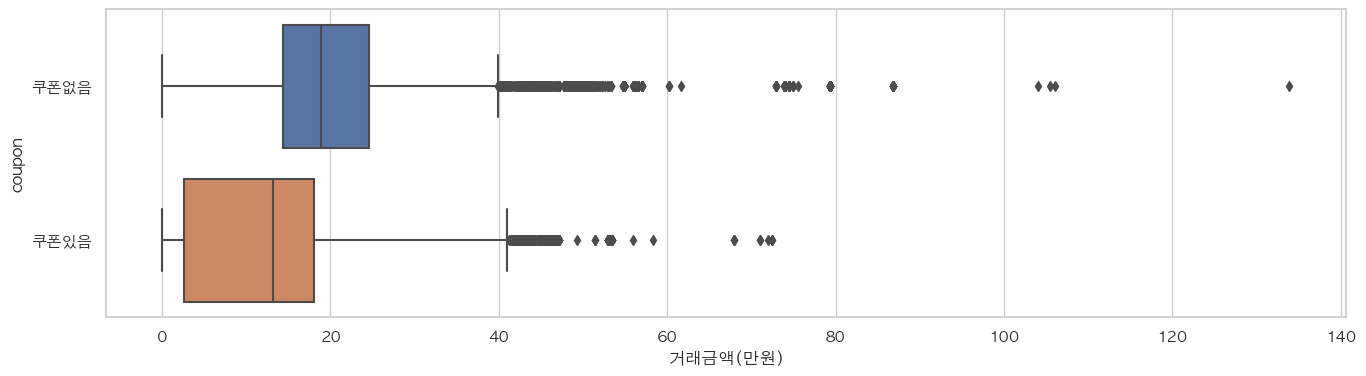

In [28]:
# boxplot 분포 확인

plt.figure(figsize=(16, 4))
sns.boxplot(
    df,
    y=df["coupon"].apply(lambda x: "쿠폰있음" if x else "쿠폰없음"),
    x=df["거래금액"].apply(lambda x: x / 10000),
)
plt.xlabel("거래금액(만원)")
plt.show()


# **3. 프로젝트의 예상 결과와 실제 결과 비교**

1. ### 예상 
	- 쿠폰에 따라 매출등이 달라 질 것이라 예상
		- 쿠폰 운영 전략에 대해 다룸
	-    
	- 
	- 아래 그래프는 1년간 사용된 쿠폰의 종류, 할인율을 나타내는 scatterplot 임
	- *매월 초에 파란기둥*이 있는걸 확인 할 수 있음
	- 파란색은 *프로모션 쿠폰이며, 50~100%정도의 높은 할인율의 쿠폰을 주기적으로 발행*한다는 것을 알수 있음
	- *0~30% 할인율*로 밑에 전체적으로 깔려있는 *초록색은 WELCOME 쿠폰*으로 신규가입자에게 뿌리는것으로 *꾸준히 발행*됨

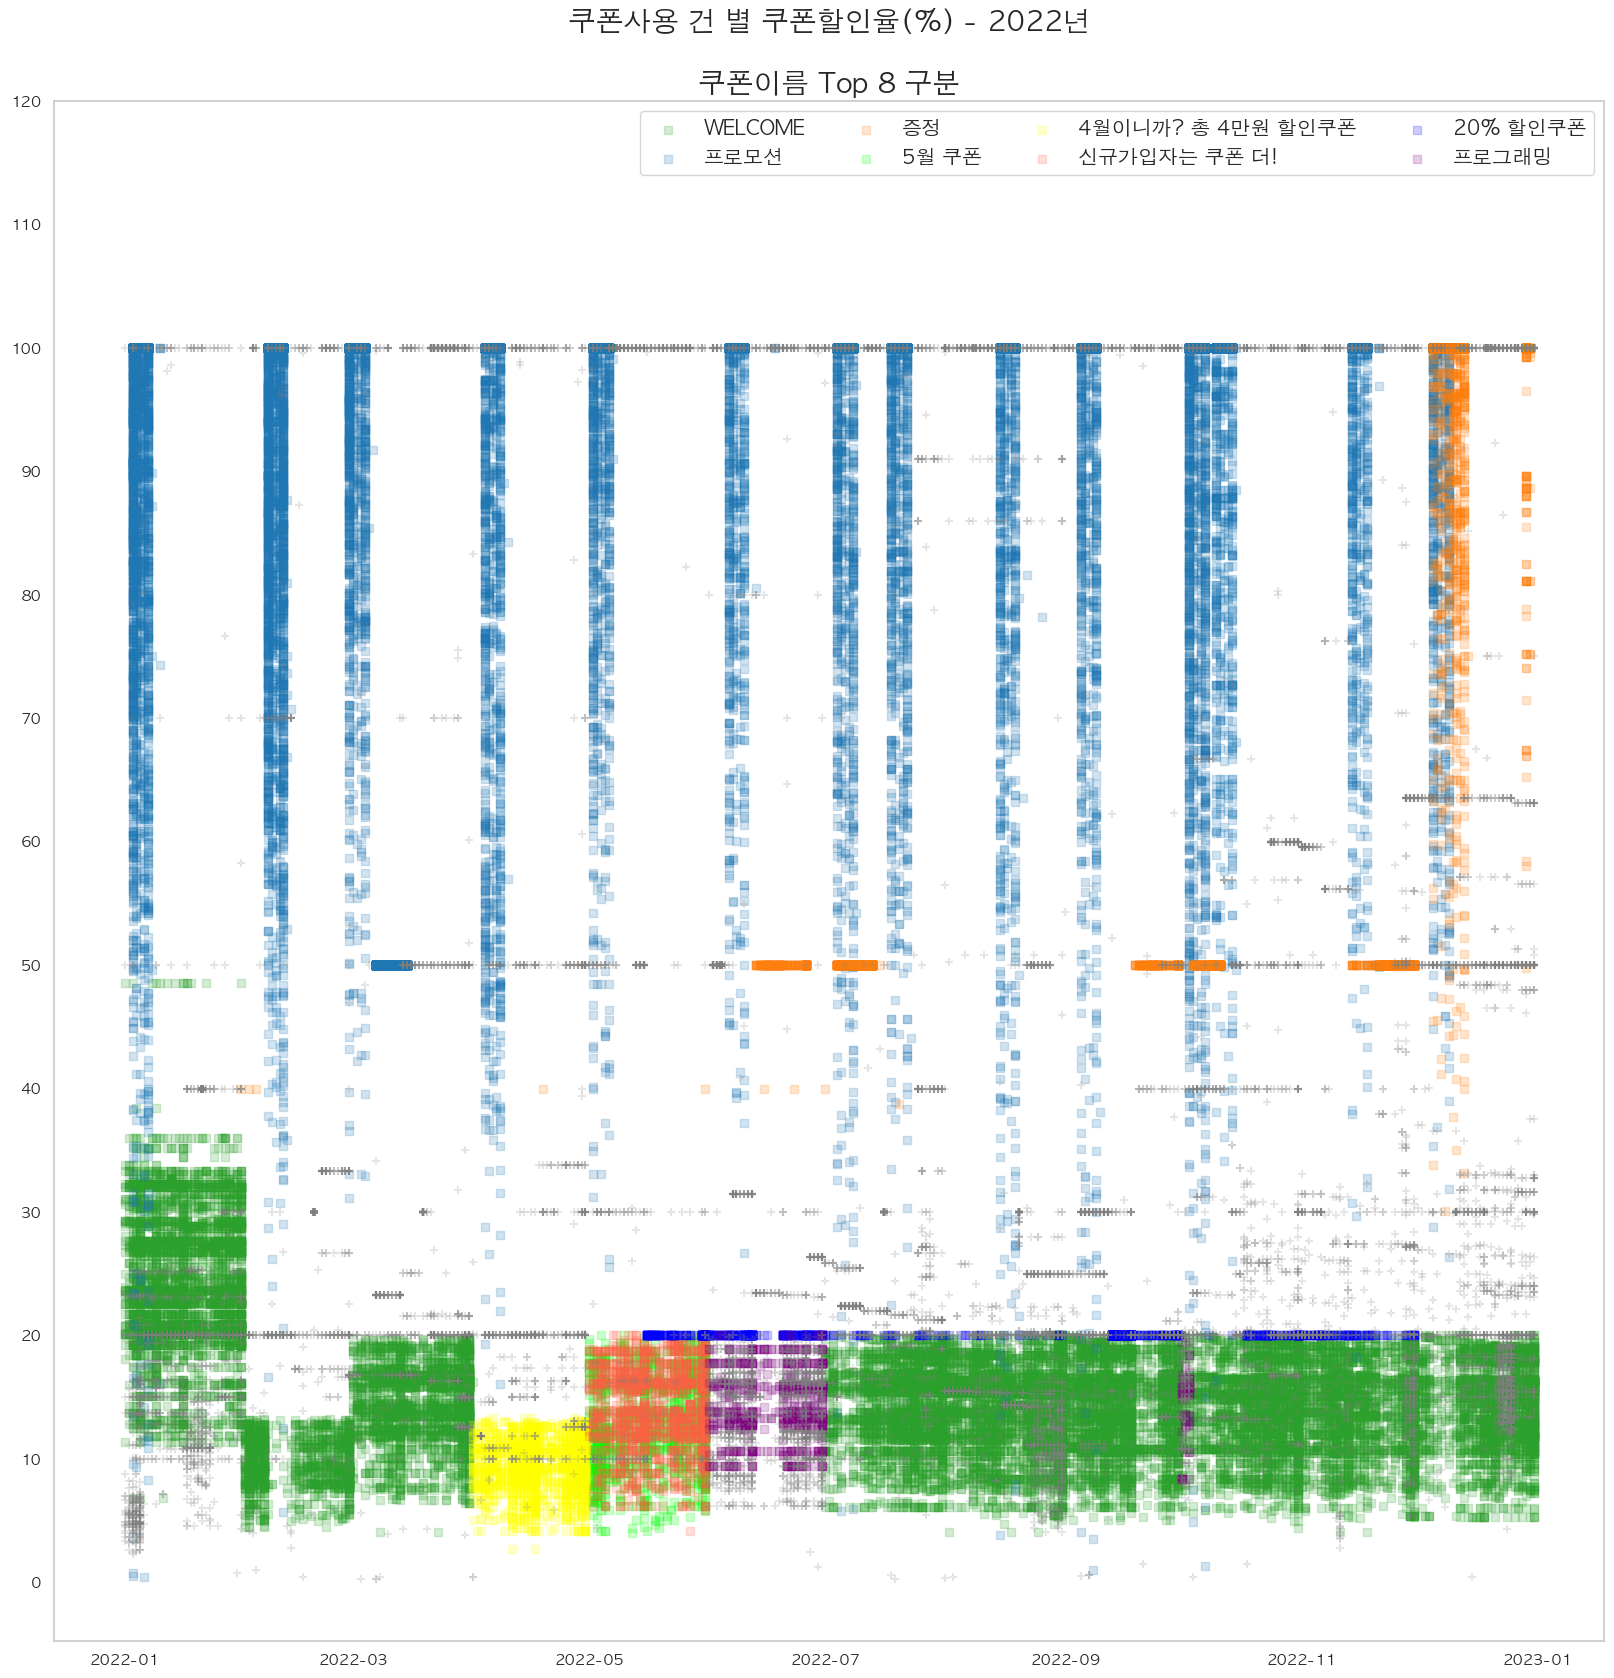

In [29]:
# scatter plot : year

# scatterplot text를 위한 전처리
df.loc[df["cp_tag"] == "WELCOME", "cp_tag"] = "웰컴"
df.loc[df["cp_tag"] == "프로모션", "cp_tag"] = "프모"
df.loc[df["cp_tag"] == "5월 쿠폰", "cp_tag"] = "5월"
df.loc[df["cp_tag"] == "4월이니까? 총 4만원 할인쿠폰", "cp_tag"] = "4월"
df.loc[df["cp_tag"] == "신규가입자는 쿠폰 더!", "cp_tag"] = "신규"
df.loc[df["cp_tag"] == "20% 할인쿠폰", "cp_tag"] = "20%"
df.loc[df["cp_tag"] == "프로그래밍", "cp_tag"] = "프밍"

show_cp_tag = df["cp_tag"].value_counts().head(8)  # 상위 8개를 보여주기로 결정
show_cp_tag = show_cp_tag.to_frame(name="color")

# show_cp_tag에 컬러 추가
show_cp_tag["color"] = [
    "tab:green",
    "tab:blue",
    "tab:orange",
    "lime",
    "yellow",
    "tomato",
    "blue",
    "purple",
]

# scatter plot : year

# 할인율('할인금액조정'/'판매가격') 빈도수 22년
plt.figure(figsize=(20, 20))

# show_cp_tag 갯수 만큼 scatter 만들기
cp_tag_df = df[df["할인금액조정"] > 0][["p_date", "할인금액조정", "판매가격", "cp_tag"]]
for cp_tag in show_cp_tag.index:
    x = cp_tag_df[cp_tag_df["cp_tag"] == cp_tag]["p_date"]
    y = (
        cp_tag_df[cp_tag_df["cp_tag"] == cp_tag]["할인금액조정"]
        / cp_tag_df[cp_tag_df["cp_tag"] == cp_tag]["판매가격"]
        * 100
    )

    plt.scatter(
        x,
        y,
        marker="s",
        label=cp_tag,
        alpha=0.2,
        c=show_cp_tag.loc[cp_tag, "color"],
    )

# show_cp_tag 외 만들기
cp_tag_df = df[
    (df["할인금액조정"] > 0) & ((df["cp_tag"].isin(show_cp_tag.index)) == False)
][["p_date", "할인금액조정", "판매가격", "cp_tag"]]
x = cp_tag_df["p_date"]  # x축은 일자입니다. 20220101 ~ 20221231
y = cp_tag_df["할인금액조정"] / cp_tag_df["판매가격"] * 100  # y축은 할인율% 입니다. 0% ~ 100%

plt.scatter(x, y, marker="+", label="나머지", alpha=0.2, c="grey")

# 출력
plt.title(
    "쿠폰사용 건 별 쿠폰할인율(%) - 2022년\n\n쿠폰이름 Top 8 구분", fontsize=20, fontweight="bold"
)
labels = [
    "WELCOME",
    "프로모션",
    "증정",
    "5월 쿠폰",
    "4월이니까? 총 4만원 할인쿠폰",
    "신규가입자는 쿠폰 더!",
    "20% 할인쿠폰",
    "프로그래밍",
]
plt.legend(labels=labels, loc="upper right", ncol=4, fontsize="large")
plt.yticks(range(0, 130, 10))  # y축의 range 지정 0 ~ 110 까지 10단위로 증가
plt.grid()
plt.show()


-  pieplot
- 쿠폰사용과 미사용의 비율을 보여줌
- 쿠폰을 사용하지 않은 그룹이 조금더 많은것을 알 수있음

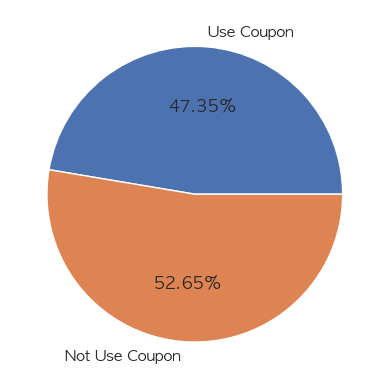

In [30]:
# pieplot 쿠폰사용 쿠폰미사용 비율
plt.pie(
    x=[len(df_useCoupon), len(df_notuseCoupon)],
    labels=["Use Coupon", "Not Use Coupon"],
    autopct="%.2f%%",
)
plt.show()


- histplot n회 거래한 사람의 숫자와 환불 비율을 나타냄 
	- *1 ~ 4회 거래하는 인원이 대부분*임, 재구매율이 높지않음

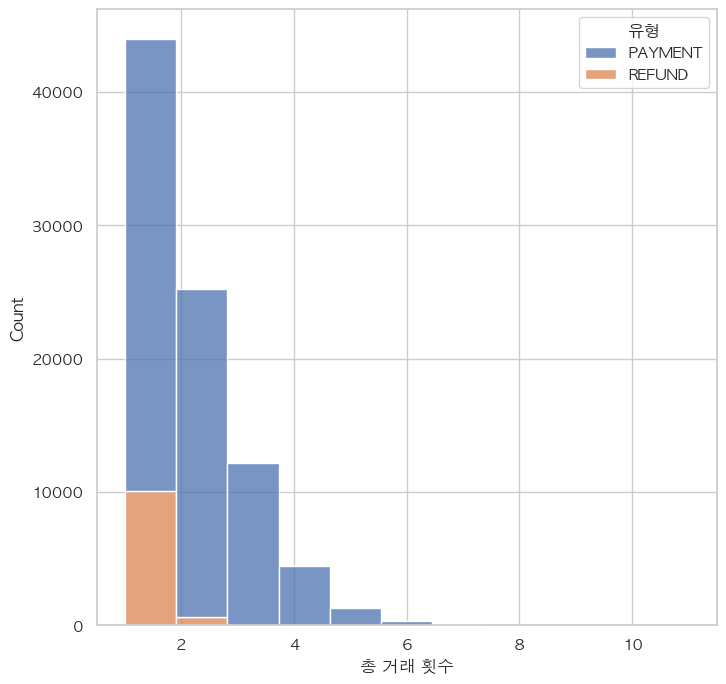

In [31]:
#
# histplot n회 거래한 사람의 숫자와 환불 비율

df_grouped = df.groupby(["고객id", "유형"]).agg("size").reset_index()
df_grouped.columns = ["고객id", "유형", "count"]
df_grouped = df_grouped[df_grouped["count"] != 0]

fig, ax = plt.subplots(figsize=(8, 8))

sns.histplot(df_grouped, x="count", bins=11, hue="유형", ax=ax, multiple="stack")
plt.xlabel("총 거래 횟수")
plt.show()


/var/folders/xy/wgpzd7457379pl9984xt0q_h0000gn/T/ipykernel_26741/1839507824.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax0.set_xticklabels(labels)


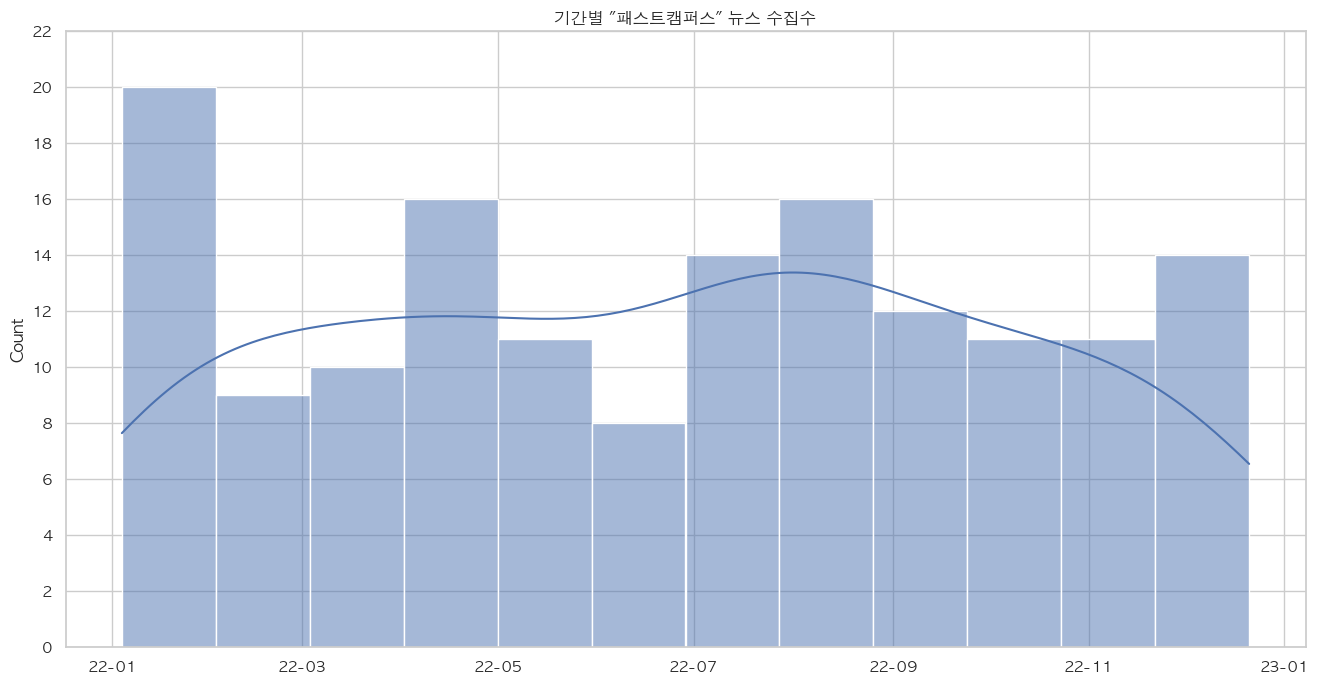

In [32]:
# histplot 월별 '패스트캠퍼스' 뉴스 발행수 그래프 (15일간격)


df_fast = pd.read_excel("./data/패스트캠퍼스_(2022.01.01~2022.12.31).xlsx")
df_fast = df_fast.drop_duplicates(
    subset=["title", "contents"], keep="first", ignore_index=True
)
df_fast["years"] = pd.to_datetime(df_fast["years"], format="%Y.%m.%d.")
df_fast = df_fast.dropna()
fig, ax = plt.subplots(figsize=(16, 8))
ax0 = sns.histplot(df_fast, x="years", bins=12, ax=ax, kde=True)
# x축 레이블 수정
labels = [item.get_text()[2:] for item in ax0.get_xticklabels()]
ax0.set_xticklabels(labels)
# y축 눈금 2단위로 조정
max_tick = int(ax0.get_yticks().max())
plt.yticks(range(0, max_tick + 2, 2))
# x축 레이블 지우기
plt.xlabel("")
# 그래프 제목 표시
plt.title('기간별 "패스트캠퍼스" 뉴스 수집수')
# 그래프 출력
plt.show()


-  lineplot 월별 총 쿠폰 할인액 및 거래금액
	- 매출과 쿠폰할인액(마케팅비용) 이 어느정도 상관관계를 보이는듯 하나 *8,9월은 쿠폰할인액과 상관없이 매출이 높게 유지*되는 것을 볼 수있음

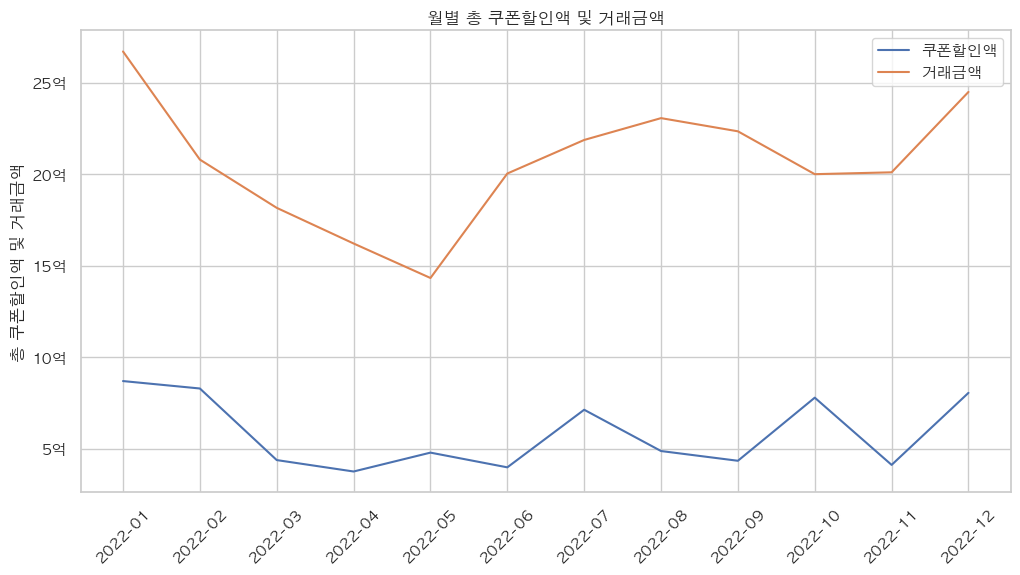

In [33]:
# lineplot 월별 총거래금액(유형이 PAYMENT인 거래금액의 합) 쿠폰할인액의 총합을 꺾은선 그래프
# 월별 총거래금액(유형이 PAYMENT인 거래금액의 합)과 쿠폰할인액의 총합을 꺾은선그래프로 비교하여 상관관계 분석

# 'p_date' 칼럼의 데이터를 datetime 형식으로 바꾸고, 새 칼럼에 저장
df["p_date_datetime"] = pd.to_datetime(df["p_date"])

# 월별로 데이터를 그룹화하고, 각 월별 쿠폰 할인액 합계를 계산
monthly_discount_sum = (
    df[df["유형"] == "PAYMENT"]
    .groupby(df["p_date_datetime"].dt.to_period("M"))["할인금액조정"]
    .sum()
    .reset_index()
)

# 월별로 데이터를 그룹화하고, 각 월별 거래금액 합계를 계산
monthly_transaction_sum = (
    df[df["유형"] == "PAYMENT"]
    .groupby(df["p_date_datetime"].dt.to_period("M"))["거래금액"]
    .sum()
    .reset_index()
)

# 그림 크기 지정
plt.figure(figsize=(12, 6))

# 쿠폰할인액 꺾은선그래프 그리기
plt.plot(
    monthly_discount_sum["p_date_datetime"].astype(str),
    monthly_discount_sum["할인금액조정"],
    label="쿠폰할인액",
)

# 총거래금액 꺾은선그래프 그리기
plt.plot(
    monthly_transaction_sum["p_date_datetime"].astype(str),
    monthly_transaction_sum["거래금액"],
    label="거래금액",
)

# y축 레이블 지정
plt.ylabel("총 쿠폰할인액 및 거래금액")

# y축 눈금 서식 변경
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x/100000000:,.0f}억")

# 그래프 제목 지정
plt.title("월별 총 쿠폰할인액 및 거래금액")

# x축 눈금 라벨 회전
plt.xticks(rotation=45)

# 범례 표시
plt.legend()

# 그래프 표시
plt.show()

# 어느 정도 관계성은 보이나, 온전히 비례한다고 하긴 힘들다 판단됨.


- 월별 쿠폰 사용율
	- 전체적으로 *50%에 가까우나 미사용이 조금 더 많음

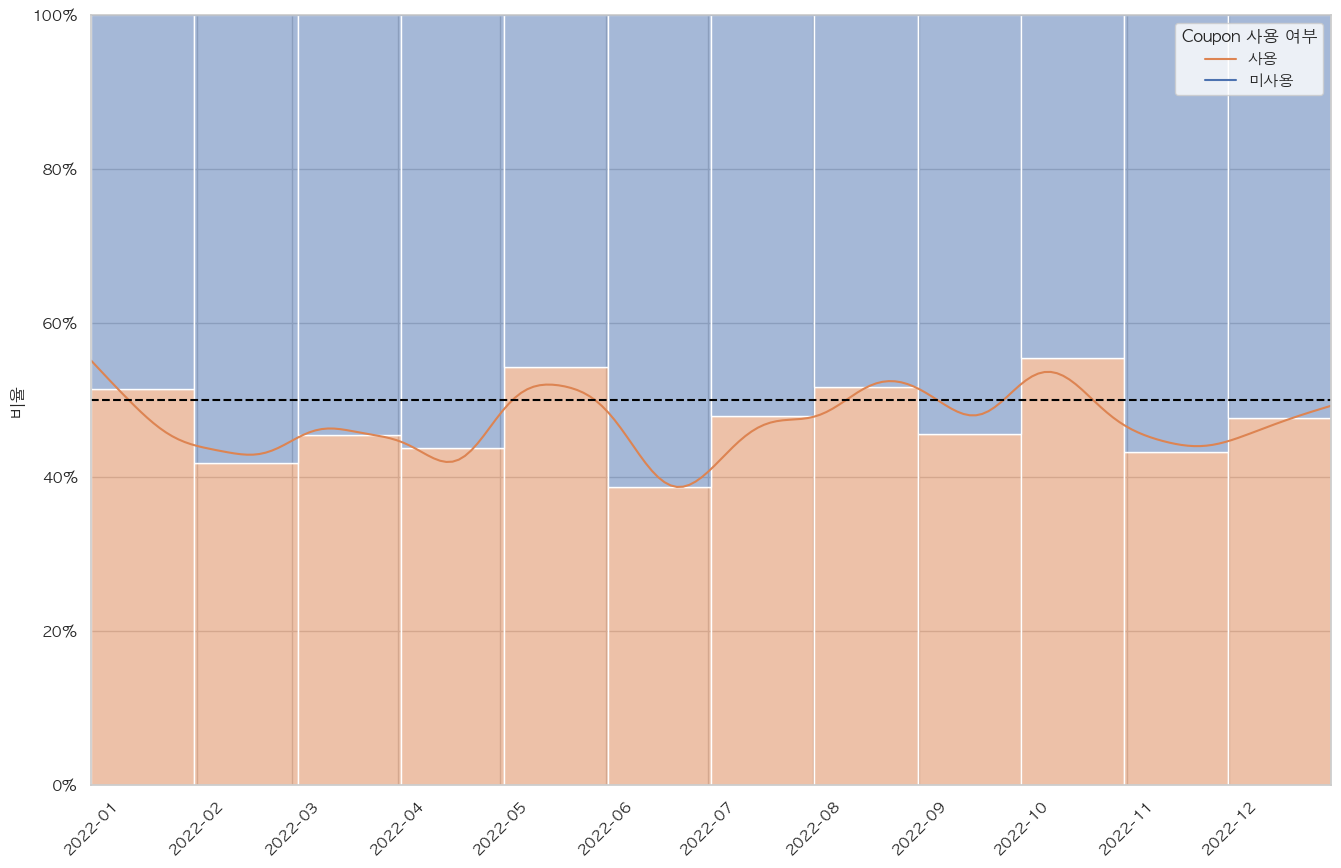

In [34]:
# histplot 기간별 쿠폰 사용 비율
fig, ax = plt.subplots(figsize=(16, 10))

# histogram 그리기
ax = sns.histplot(
    df, x="p_date", bins=12, hue="coupon", kde=True, ax=ax, multiple="fill"
)

# 범례 추가
ax.legend(title="Coupon 사용 여부", labels=["사용", "미사용"])

# x축 이름과 y축 이름 설정
ax.set(xlabel="", ylabel="비율")

# y축을 백분율로 바꾸기
def to_percent(y, position):
    return str(round(y * 100)) + "%"


ax.yaxis.set_major_formatter(mtick.FuncFormatter(to_percent))  ##???

# 그래프 출력
plt.ylim(0, 1)
plt.axhline(y=0.5, color="black", linestyle="--")
plt.xticks(rotation=45)
plt.show()


- 기간별 '코딩' 키워드 네이버 뉴스 발행수 ( 크롤링으로 수집 )
	- 꾸준히 발행수가 높아지긴 하지만 *8월과 연말에  많이 발행*된 것을 알 수 있음
	- 해당 기간에 코딩에 대한 *사회적 관심도가 높아* 졌다고 볼 수 있음
	- *8월에 쿠폰할인율이 빠졌지만 매출이 유지된 이유*라고 판단함

/var/folders/xy/wgpzd7457379pl9984xt0q_h0000gn/T/ipykernel_26741/2787584036.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax0.set_xticklabels(labels)


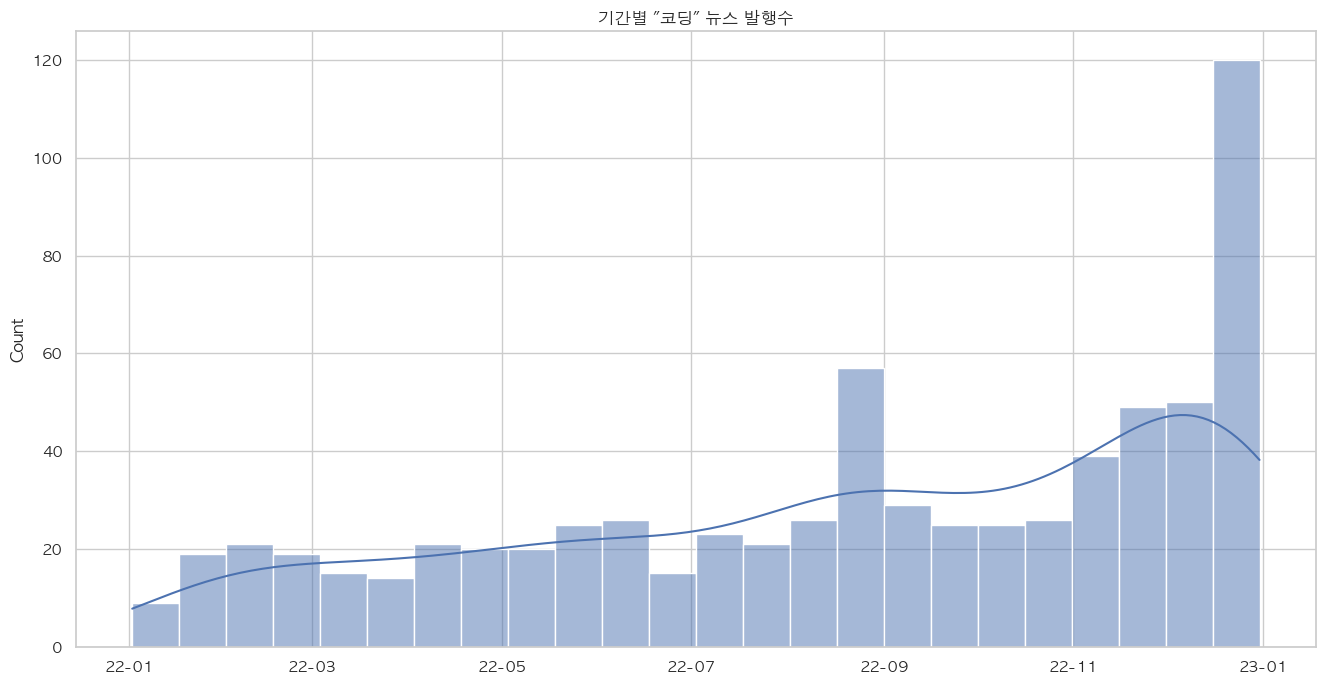

In [35]:
# histplot 월별 '코딩' 뉴스 발행수 그래프 (15일간격) - 최
# 해당기간에 많이 발행되었다. -> 사회적 관심도가 높다, 8월에 쿠폰할인액이 빠지는데 거래금액은 꾸준히 높게 유지되는것 확인 가능
df_coding = pd.read_excel("./data/코딩2_(2022.01.01~2022.12.31).xlsx")

df_coding = df_coding.drop_duplicates(
    subset=["title", "contents"], keep="first", ignore_index=True
)
df_coding["years"] = pd.to_datetime(df_coding["years"], format="%Y.%m.%d.")
df_coding = df_coding.dropna()
fig, ax = plt.subplots(figsize=(16, 8))
ax0 = sns.histplot(df_coding, x="years", bins=24, ax=ax, kde=True)
labels = [item.get_text()[2:] for item in ax0.get_xticklabels()]
ax0.set_xticklabels(labels)
plt.xlabel("")
plt.title('기간별 "코딩" 뉴스 발행수')
plt.show()


- 월별 프로그래밍 수강 비율
	- *매출이 높은 시기에 프로그래밍 수강수도 높아짐

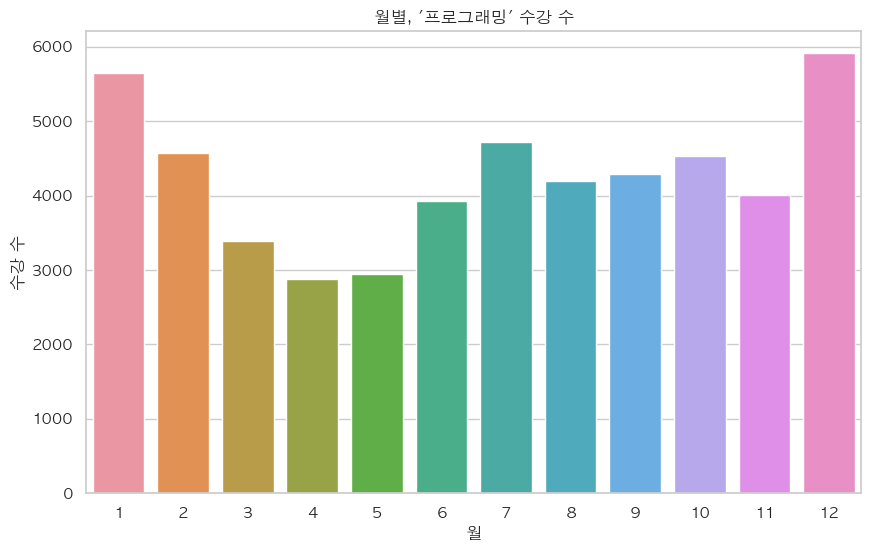

In [36]:
# 월별로 프로그래밍이 수강이 제일 높았는지 ?
count_month = [0] * 12
for x in df[df["카테고리"] == "프로그래밍"]["p_date"]:
    count_month[int(str(x).split("-")[1]) - 1] += 1

df_month = pd.DataFrame({"월": np.arange(1, 13), "수강 수": count_month})

# seaborn barplot 사용
plt.figure(figsize=(10, 6))
sns.barplot(x="월", y="수강 수", data=df_month)
plt.title("월별, '프로그래밍' 수강 수")
plt.show()


- 시간별 결제량, 요일별 결제량
	- 저녁시간에 결제량이 많음
	- 월요일, 금요일,  일요일에 결제량이 많음
	- 주 고객층이 성인이다 보니 평일엔 바쁘게 지내다가 금요일엔 '아 이번주말은 잘 보내야 겠다',
	- 일요일, 월요일엔 '아 이번주 너무 놀았네,' 현타를 느끼며 '이제부터 다시 열심히 살아야겠다' 라고 생각하는 사람이 많아 결제량과 쿠폰사용량이 늘어나는 시나리오를 그려볼 수 있음

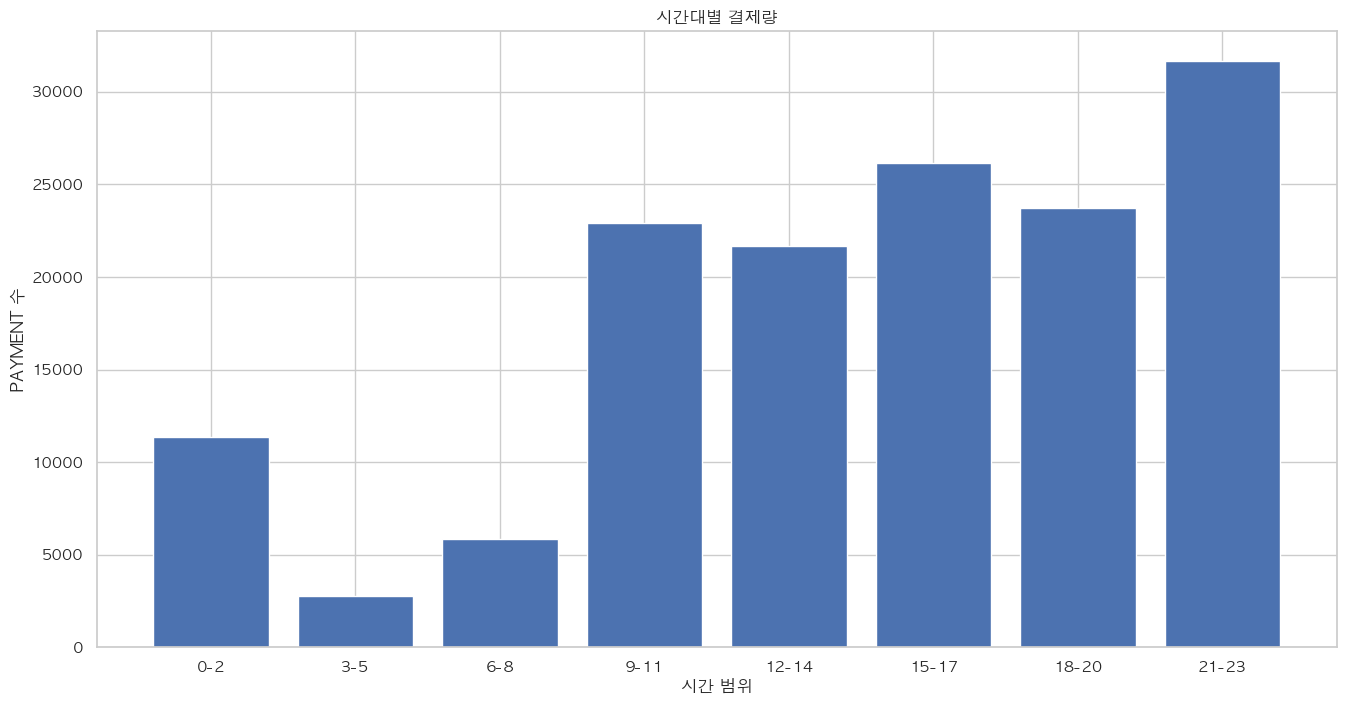

In [37]:
# barplot 시간대별(3시간단위) 결제량 - 박
df['p_time'] = df['p_time'].replace(24, 0)

# p_time 칼럼의 값을 3시간 단위로 나누기
bins = [0, 3, 6, 9, 12, 15, 18, 21, np.inf]  # 경계값 만들기, np.inf는 np.inf는 numpy 라이브러리에서 제공하는 무한대를 의미하는 상수. 오른쪽 상한값을 지정하는 것.
labels = ['0-2', '3-5', '6-8', '9-11', '12-14', '15-17', '18-20', '21-23']
df['time_range'] = pd.cut(df['p_time'], bins, labels=labels, right=False)

# 'time_range'와 '유형'을 기준으로 데이터 그룹화 및 시간대별 'PAYMENT' 수 계산
payment_by_time_range = df[df['유형'] == 'PAYMENT'].groupby('time_range').size()

# 결과 데이터프레임 리셋 인덱스(인덱스 순서를 재정렬)
payment_by_time_range = payment_by_time_range.reset_index(name='count')

plt.figure(figsize=(16,8))
# 그래프 그리기
plt.bar(payment_by_time_range['time_range'], payment_by_time_range['count'])
# x축과 y축 라벨 설정
plt.xlabel('시간 범위')
plt.ylabel('PAYMENT 수')

# 그래프 제목을 부여하고 출력
plt.title('시간대별 결제량')
plt.show()

# 야무지게 놀다가 하루의 막바지에 내일부턴 열심히 살아야지.

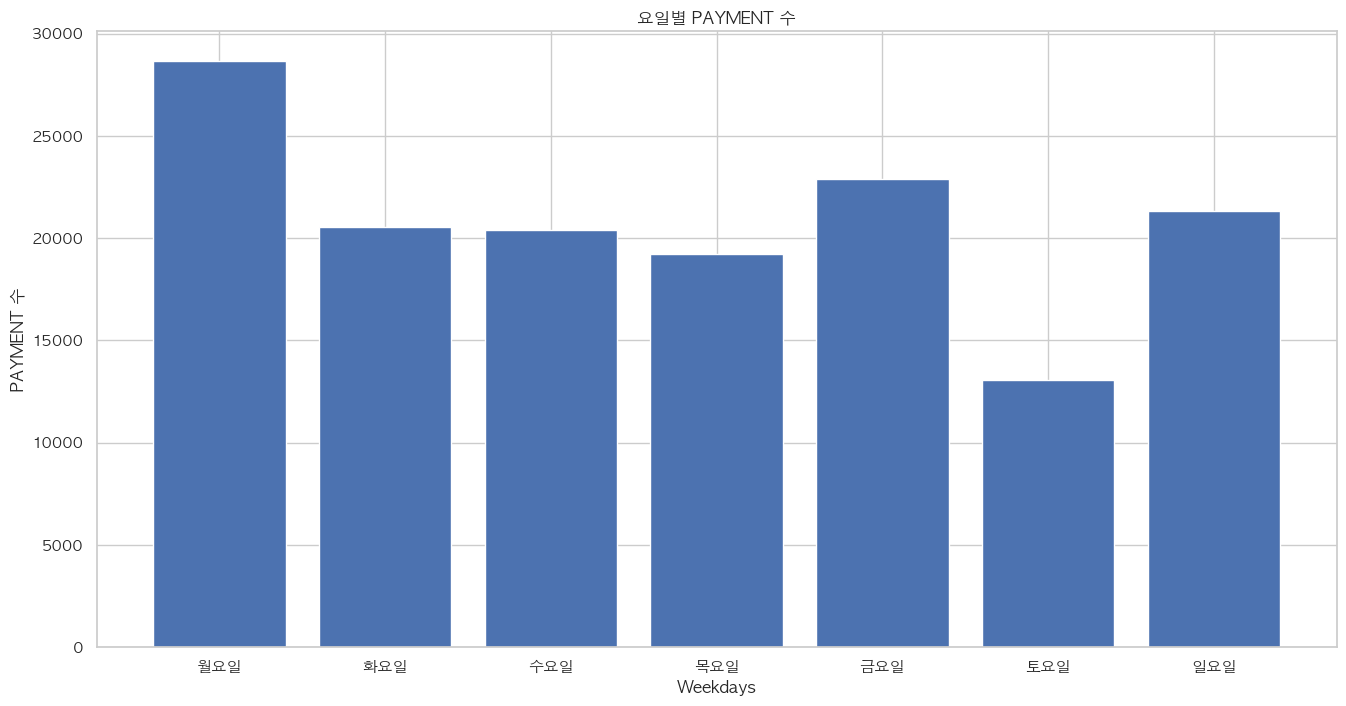

In [38]:
# barplot 요일 별로 PAYMENT가 얼마나 발생했는지 - 박
payment_by_day = df[df["유형"] == "PAYMENT"].groupby("p_week").size()

payment_by_day = payment_by_day.reset_index(name="count")

day_order = ["월요일", "화요일", "수요일", "목요일", "금요일", "토요일", "일요일"]
payment_by_day["p_week"] = pd.Categorical(
    payment_by_day["p_week"], categories=day_order, ordered=True
)
payment_by_day = payment_by_day.sort_values("p_week")
plt.figure(figsize=(16, 8))

# 막대그래프 그리기
plt.bar(payment_by_day["p_week"], payment_by_day["count"])

# x축과 y축 라벨 설정
plt.xlabel("Weekdays")
plt.ylabel("PAYMENT 수")


# 그래프 제목을 부여하고 출력
plt.title("요일별 PAYMENT 수")
plt.show()

# 월요일에 새로운 마음으로 시작하고 토요일에 한껏 나태해진다.


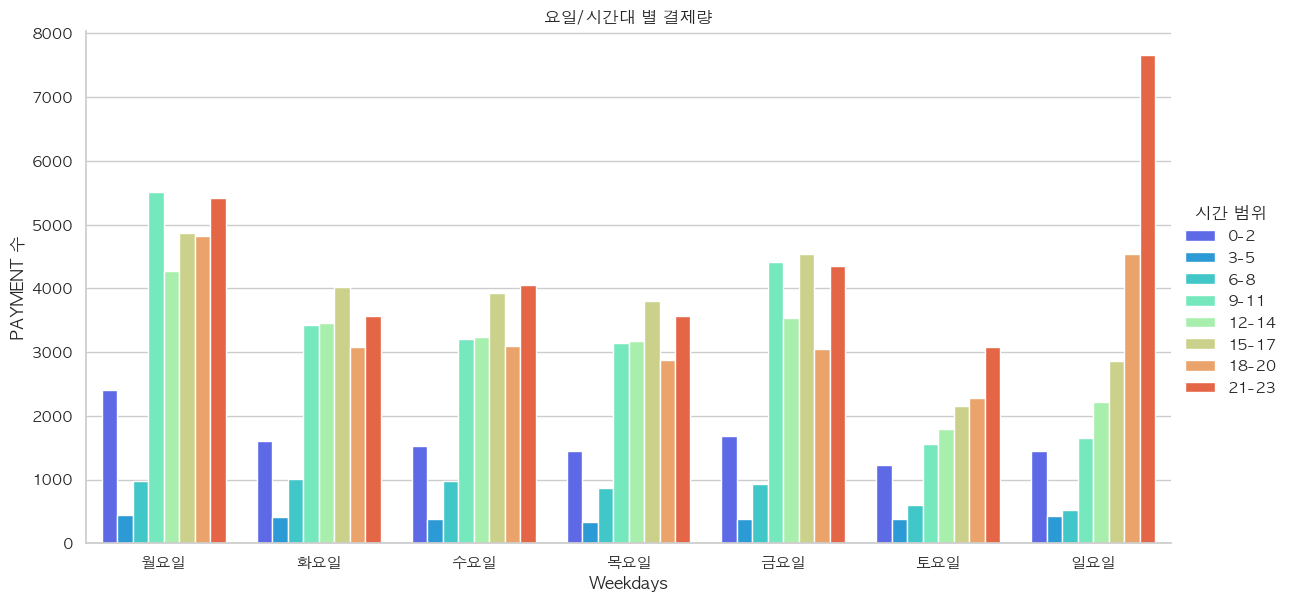

In [39]:
# barplot 요일별 시간대별 결제량
# 각 요일마다 어느 시간대에 결제가 많이 발생했는지 그래프로 나타내기

# 유형칼럼의 'PAYMENT' 데이터만 추출
payment_df = df[df["유형"] == "PAYMENT"]

# 요일 별 그룹화 후, 각 요일에서 시간 범위별로 그룹화하여 결제 건수를 계산
payment_by_weekday_time_range = (
    payment_df.groupby(["p_week", "time_range"])
    .size()
    .reset_index(name="count")
)

# x축 순서(인덱스 순서)를 정하고 정렬하기
weekday_order = ["월요일", "화요일", "수요일", "목요일", "금요일", "토요일", "일요일"]
payment_by_weekday_time_range["p_week"] = pd.Categorical(
    payment_by_weekday_time_range["p_week"],
    categories=weekday_order,
    ordered=True,
)
payment_by_weekday_time_range = payment_by_weekday_time_range.sort_values(
    "p_week"
)

# Seaborn Catplot을 사용하여 요일 별 시간대 별 PAYMENT 수를 그래프로 만들기
g = sns.catplot(
    x="p_week",
    y="count",
    hue="time_range",
    data=payment_by_weekday_time_range,
    kind="bar",
    palette="rainbow",
    height=6,
    aspect=2,
)

# x축과 y축 라벨 설정
g.set_axis_labels("Weekdays", "PAYMENT 수")

# 범례 제목 설정
g.legend.set_title("시간 범위")

# 그래프 제목을 부여하고 출력
plt.title("요일/시간대 별 결제량")
plt.show()


# 일요일 잠들기 전 발전적인 다음주를 꿈꾸며 잠들기 전 결제, 매일 발전적인 내일을 꿈꾸며 잠들기 전 결제.


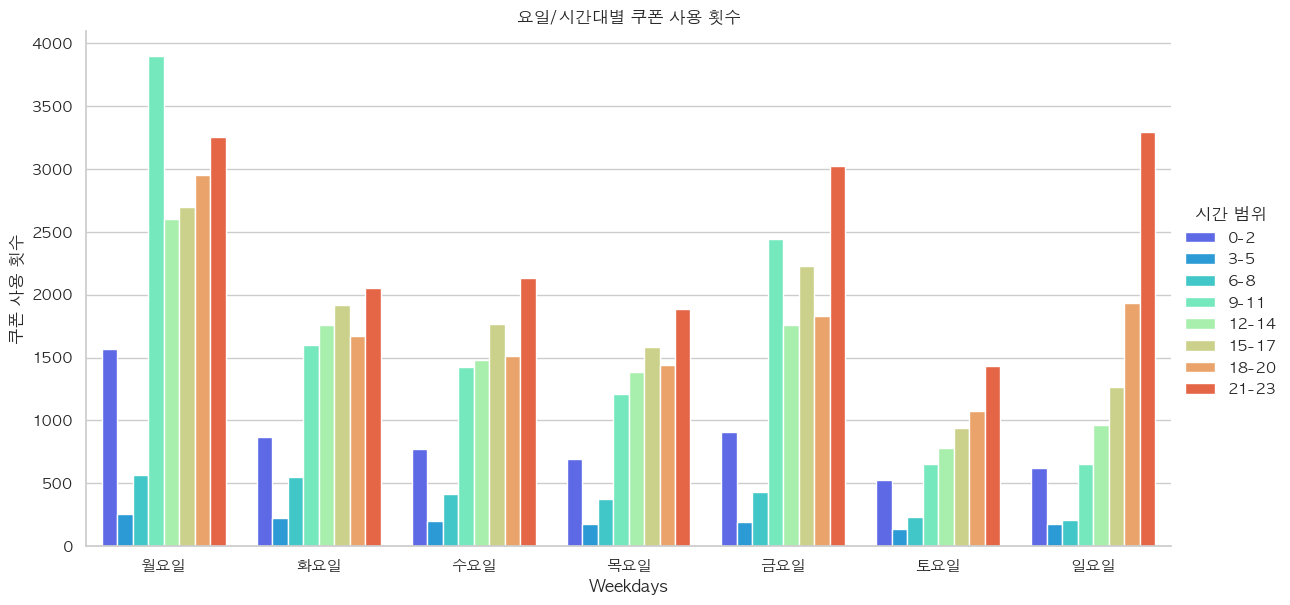

In [40]:
# barplot  요일/시간대별 쿠폰사용횟수를 그래프로 나타냄 - 박
# 쿠폰 사용여부가 PAYMENT 발생에 얼마나 영향을 끼쳤는지 확인해보기

# '쿠폰할인액'이 있으면서 '유형' 칼럼이 'PAYMENT'인 데이터만 추출
coupon_payment_df = payment_df[
    (payment_df["쿠폰할인액"] > 0) & (payment_df["유형"] == "PAYMENT")
]

# 시간대별, 요일별 그룹화 후, 쿠폰 사용 횟수 계산
coupon_payment_by_weekday_time_range = (
    coupon_payment_df.groupby(["p_week", "time_range"])
    .size()
    .reset_index(name="coupon_count")
)

# x축 순서(인덱스 순서)를 정하고 정렬하기
weekday_order = ["월요일", "화요일", "수요일", "목요일", "금요일", "토요일", "일요일"]
coupon_payment_by_weekday_time_range["p_week"] = pd.Categorical(
    coupon_payment_by_weekday_time_range["p_week"],
    categories=weekday_order,
    ordered=True,
)
coupon_payment_by_weekday_time_range = (
    coupon_payment_by_weekday_time_range.sort_values("p_week")
)

# Seaborn catplot을 사용하여 요일 별 시간대별 쿠폰 사용 횟수 그래프 만들기
g = sns.catplot(
    x="p_week",
    y="coupon_count",
    hue="time_range",
    data=coupon_payment_by_weekday_time_range,
    kind="bar",
    palette="rainbow",
    height=6,
    aspect=2,
)

# x축과 y축 라벨 설정
g.set_axis_labels("Weekdays", "쿠폰 사용 횟수")

# 범례 제목 설정
g.legend.set_title("시간 범위")

# 그래프 제목을 부여하고 출력
plt.title("요일/시간대별 쿠폰 사용 횟수")
plt.show()


# 쿠폰 사용 여부와 판매량간에는 정비례하는 관계가 있다. 그런데, 월요일과 금요일에 쿠폰 사용 횟수가 더욱 높게 나오는 것이 인상적. 패스트캠퍼스의 쿠폰 운용 전략과 관련이 있을 것으로 예상한다.


- 카테고리별 쿠폰 사용 비율
	- *부업/창업*, *투자/재테크* 카테고리가 *쿠폰 사용율이 다른 카테고리에 비해 높은*것을 알수 있음

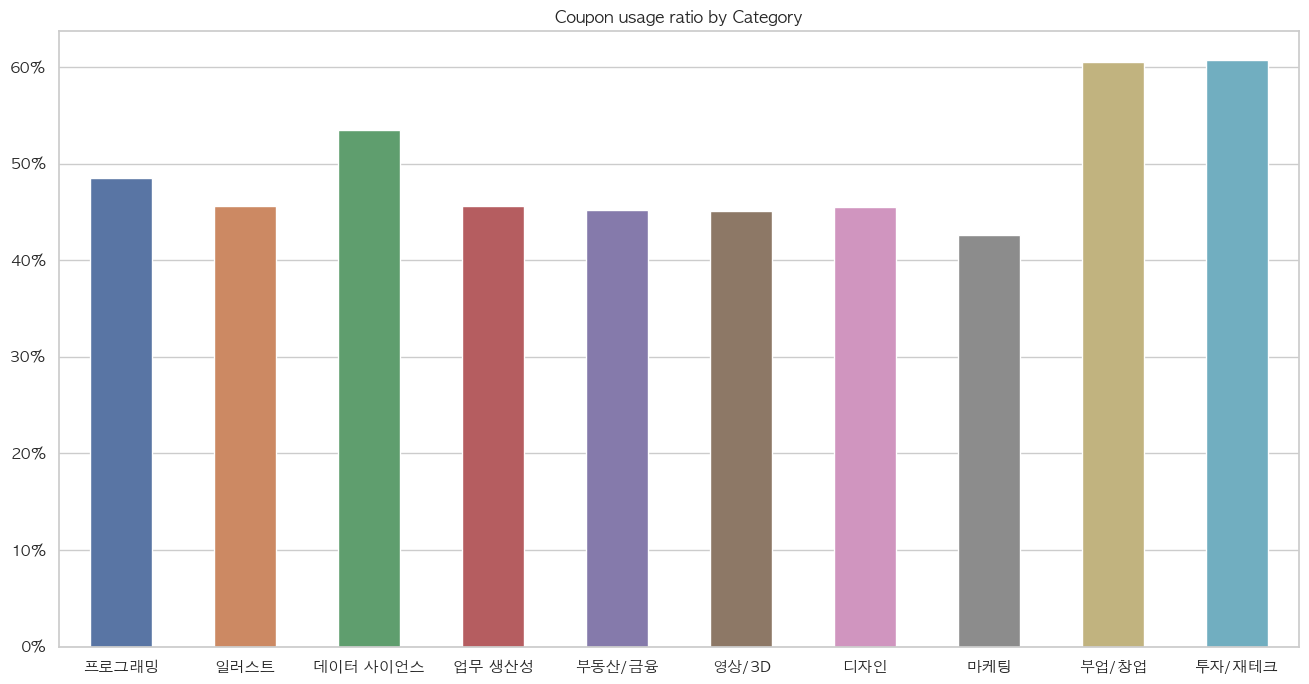

In [41]:
# barplot 쿠폰을 썼을때, 어느 카테고리에서 많이 썼을까?
import matplotlib.ticker as mticker

# 각 카테고리별 쿠폰 사용 비율 계산
temp = []
for x in range(len(df_useCoupon["카테고리"].unique())):
    pd.DataFrame(
        temp.append(
            df_useCoupon["카테고리"].value_counts()[x]
            / df["카테고리"].value_counts()[x]
        )
    )

# 카테고리별 쿠폰 사용 비율을 나타내는 막대 그래프 그리기
sns.barplot(
    data=df_useCoupon,
    x=df_useCoupon["카테고리"].unique(),
    y=temp,
    width=0.5,
)
plt.title("Coupon usage ratio by Category")
plt.gcf().set_size_inches(16, 8)

# 백분율로 y축 눈금 바꾸기
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))

# 그래프 출력
plt.show()


- 월별 카테고리별 구매횟수 그래프
	- 프로그래밍과 데이터사이언스가 꾸준히 팔림
	- 8~9월에 일러스트가 데이터사이언스를 잠깐 추월함

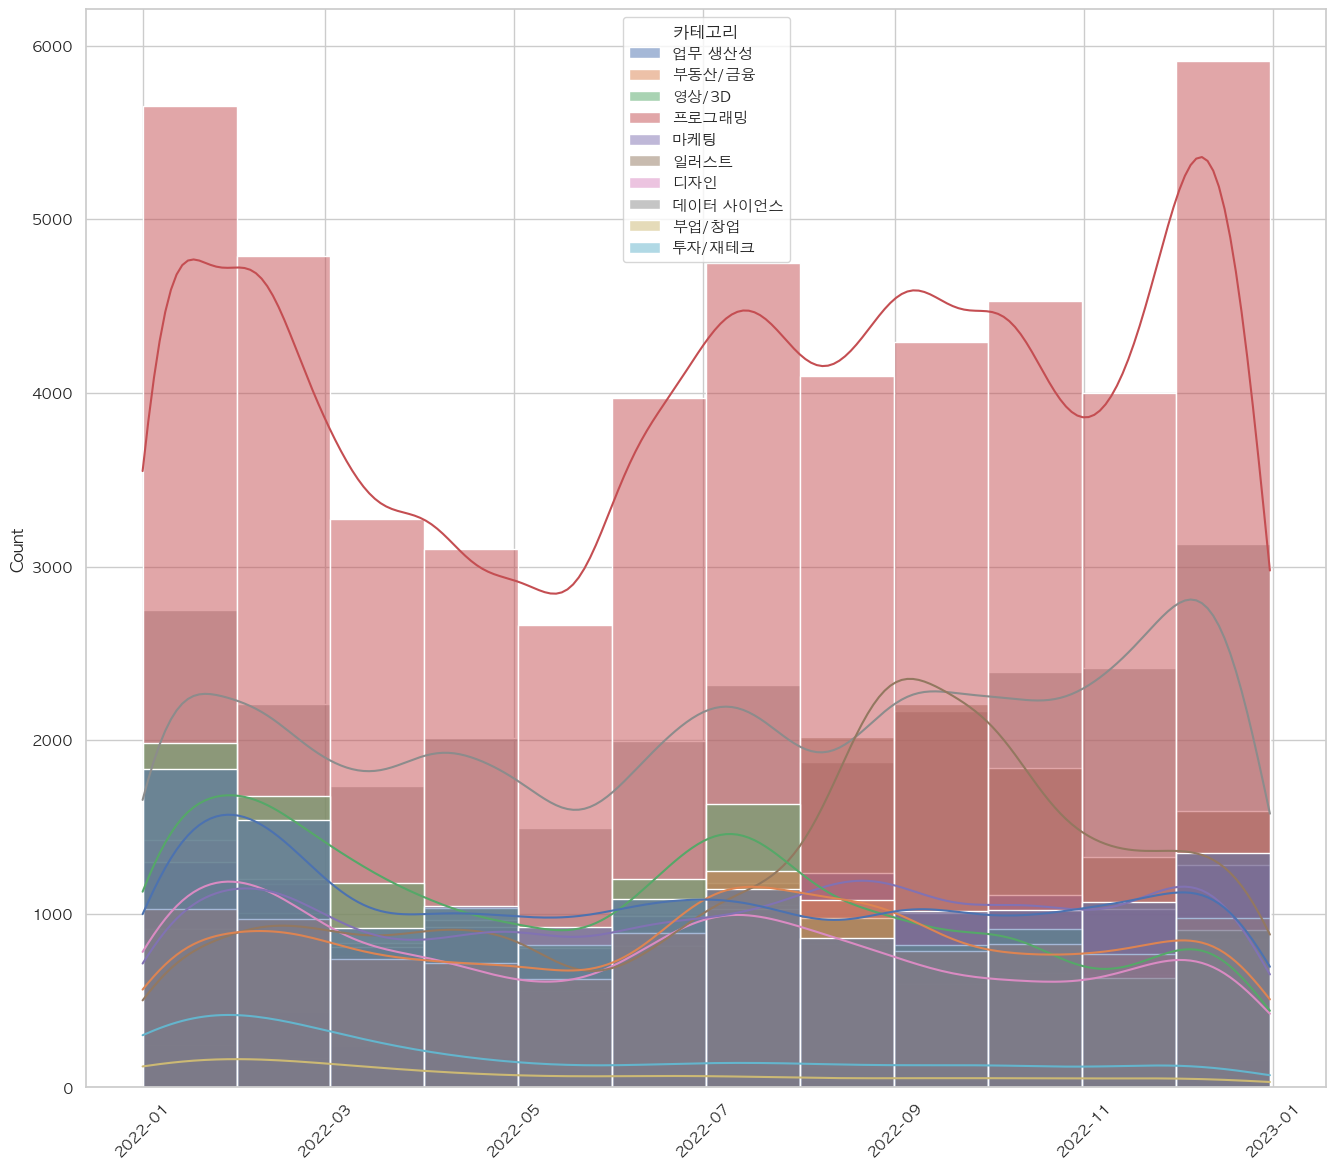

In [42]:
# histplot 월별 카테고리별 거래
plt.figure(figsize=(16, 14))
sns.histplot(df, x="p_date", bins=12, hue="카테고리", kde=True, multiple="layer")
plt.xticks(rotation=45)
plt.xlabel("")
plt.show()


-  강의수 대비 쿠폰사용비율에 대한 그래프
	-  *투자/재테크, 부업/창업 은 절대적인 강의수*가 적은데 *비해 쿠폰 사용이 많았음*
	- *프로그래밍*은 *강의수*가 많은데 *비해 쿠폰 사용 비율이 적었음*
	- *부자재테크와 부업창업* 카테고리는 커리어에 대한 공부라기 보다는 *부가적인 수업 카테고리*인 만큼, 커리어적인 다른 수업을 들으면서 *할인율이 높을때 '들어볼까?'* 하는 가벼운 마음의 *소비 심리를 예측* 해 봄

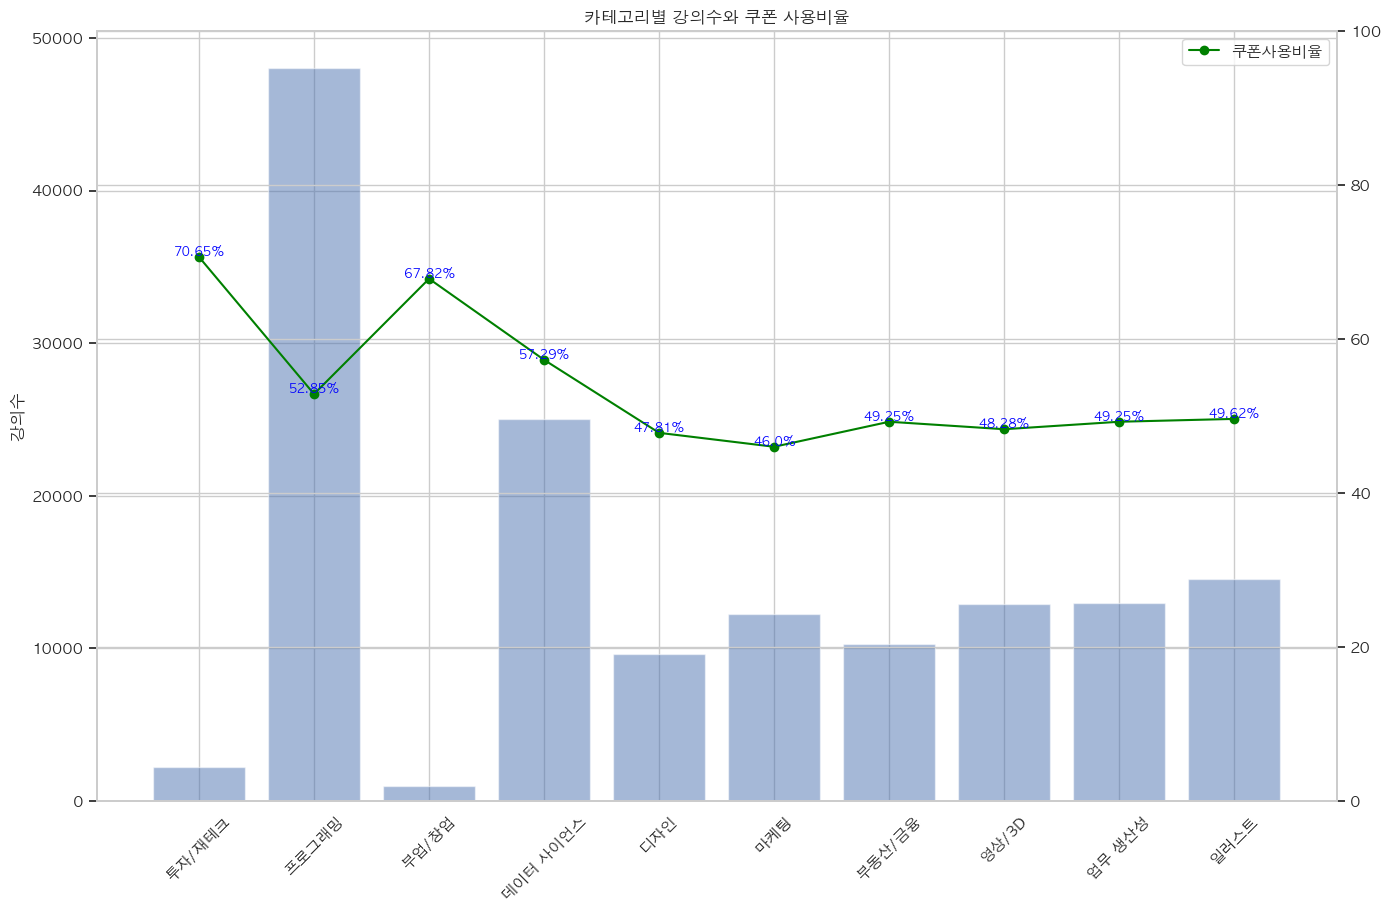

In [43]:
### 성빈님꺼 보고 일단 따라 해보기
x = [
    "투자/재테크",
    "프로그래밍",
    "부업/창업",
    "데이터 사이언스",
    "디자인",
    "마케팅",
    "부동산/금융",
    "영상/3D",
    "업무 생산성",
    "일러스트",
]

temp = [70.65, 52.85, 67.82, 57.29, 47.81, 46.0, 49.25, 48.28, 49.25, 49.62]

index2 = [
    "투자/재테크",
    "프로그래밍",
    "부업/창업",
    "데이터 사이언스",
    "디자인",
    "마케팅",
    "부동산/금융",
    "영상/3D",
    "업무 생산성",
    "일러스트",
]

values2 = [2225, 48051, 954, 25057, 9655, 12236, 10308, 12913, 12982, 14520]


# 다중 플롯을 지정 : ax1은 y1에 대한 그래프
fig, ax1 = plt.subplots(figsize=(16, 10))
ax1.bar(index2, values2, label="강의 수", alpha=0.5)

# x 축 기울이기
plt.xticks(rotation=45)


# y축 레이블 지정
plt.ylabel("강의수")

# ax2는 y2에 대한 그래프, twinx로 x축을 공유
ax2 = ax1.twinx()
ax2.plot(x, temp, label="쿠폰사용비율", marker="o", color="green")
ax2.set_ylim(0, 100)
# # 강의수 막대그래프 그리기
# plt.bar(index2, values2, label='강의 수', alpha=0.5)

# # 쿠폰사용비율 꺾은선그래프 그리기
# plt.plot(x, temp, label='쿠폰사용비율',marker='o', color='green')

# 꺽은선 그래프에 텍스트 표시해보기
for i, v in enumerate(x):
    plt.text(
        v,
        temp[i],
        s=f"{temp[i]}%",  # 좌표 (x축 = v, y축 = y[0]..y[1], 표시 = y[0]..y[1])
        fontsize=9,
        color="blue",
        horizontalalignment="center",  # horizontalalignment (left, center, right)
        verticalalignment="bottom",
    )  # verticalalignment (top, center, bottom)


# 그래프 제목 지정
plt.title("카테고리별 강의수와 쿠폰 사용비율")

# 범례 표시
plt.legend()
# x 축 기울이기
plt.xticks(rotation=45)

# 그래프 표시
plt.show()


-  2회 이상 구매 고객 카테고리별 쿠폰사용 비율
	-  *투자재테크, 부업창업*에서 *쿠폰사용 비율*이 *높음*
	- 이를 보아 투자재테크와 부업창업 카테고리는 *쿠폰배포를 공격적으로 늘려 '할인하는데 들어볼까?' 하는 심리를 더 자극하는 것이 매출에 도움이 될 것*으로 보임

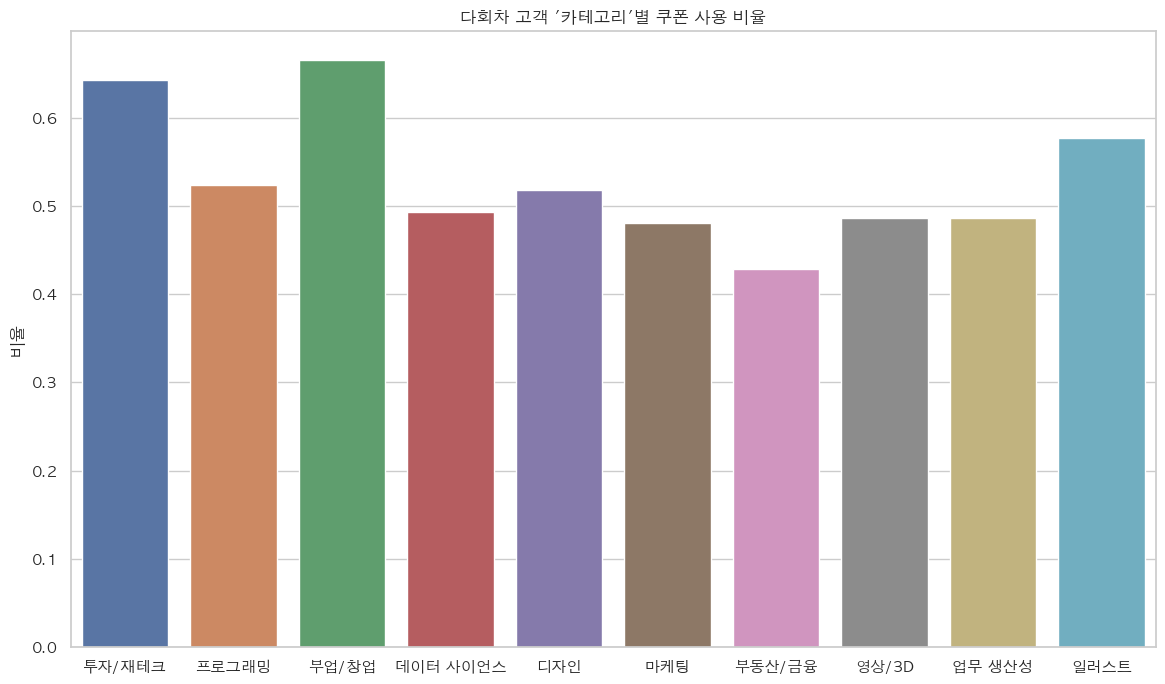

In [44]:
x = [
    "투자/재테크",
    "프로그래밍",
    "부업/창업",
    "데이터 사이언스",
    "디자인",
    "마케팅",
    "부동산/금융",
    "영상/3D",
    "업무 생산성",
    "일러스트",
]
use_coupon_counts = df_useCoupon[df_useCoupon["p_count"] > 1][
    "카테고리"
].value_counts()
df_counts = df[df["p_count"] > 1]["카테고리"].value_counts()
use_coupon_counts = use_coupon_counts.loc[x]
df_counts = df_counts.loc[x]
sns.barplot(x=x, y=use_coupon_counts / df_counts)
plt.ylabel("비율")
plt.title("다회차 고객 '카테고리'별 쿠폰 사용 비율")
plt.gcf().set_size_inches(14, 8)


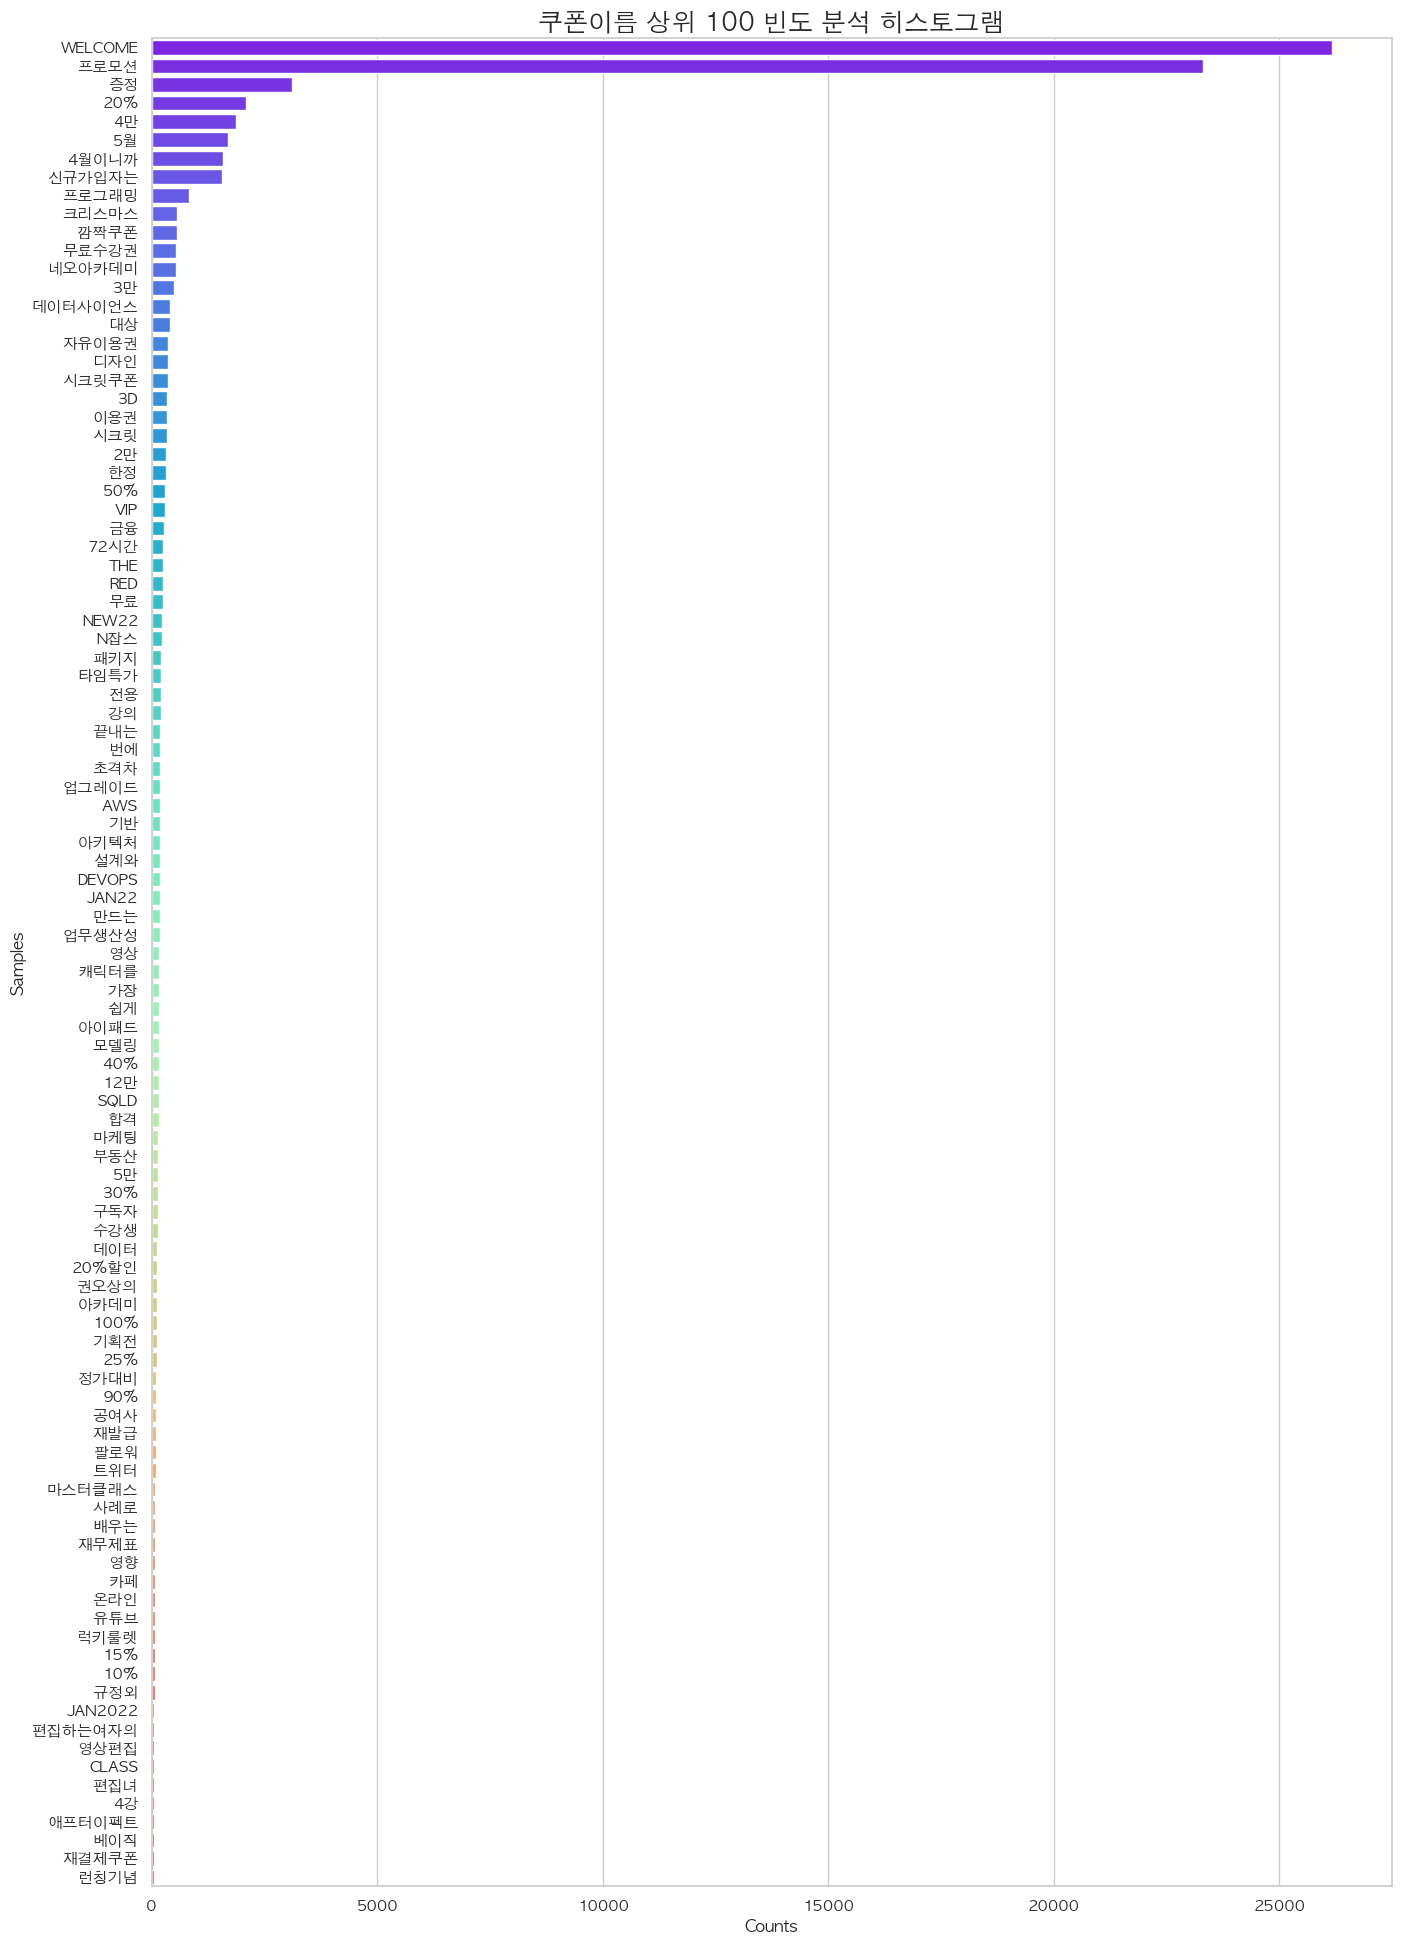

In [45]:
# word cloud 워드 클라우드 만들기 위한 코드 + barplot

topN = 100
coupon_word = df.loc[df["쿠폰이름"] != "-", "쿠폰이름"].values


def text_cleaning(doc):
    doc = " ".join(re.findall(r"\[[^\[\]]*\]", doc))
    doc = re.sub(r"(?<=\d)(0,?000)", "만", doc)
    doc = re.sub("[\{\}\[\]\/?.,;:|\)*~`!^\-_+<>@\#$&\\\=\('\"]|원", " ", doc)
    doc = doc.upper()
    return doc


def define_stopwords(path):
    SW = set()
    SW.update(["할인", "쿠폰", "할인쿠폰", "쿠폰할인"])
    with open(path, encoding="utf-8") as f:
        for word in f:
            SW.add(word.strip())
    return SW


def text_tokenizing(doc):
    return [word for word in doc.split() if word not in SW and len(word) > 1]


SW = define_stopwords("./data/stopwords-ko.txt")

tokenized_coupon = (
    df.loc[df["쿠폰이름"] != "-", "쿠폰이름"]
    .apply(text_cleaning)
    .apply(text_tokenizing)
)

total_token = [token for doc in tokenized_coupon for token in doc]


count_token = Counter(total_token).most_common(topN)

x = []
y = []
wordInfo = dict()
for word, count in count_token:
    x.append(word)
    y.append(count)
    wordInfo[word] = count

test = {"Counts": x, "Samples": y}

plt.figure(figsize=(16, 24))
plt.title("쿠폰이름 상위 %d 빈도 분석 히스토그램" % (topN), fontsize=18)
plt.ylabel("Samples")
plt.xlabel("Counts")
# plt.xticks(rotation=90)
sns.barplot(x="Samples", y="Counts", data=test, palette="rainbow")
plt.show()


-  쿠폰이름의 [ ] 안에 있는 내용의 *빈도*를 나타내는 워드클라우드
	-  처음에 본 scatterplot 에서 볼 수 있었듯이 *웰컴, 프로모션, 신규가입자는, 5월, 증정* 등이 *많이 사용*되었다는 것을 알 수 있음

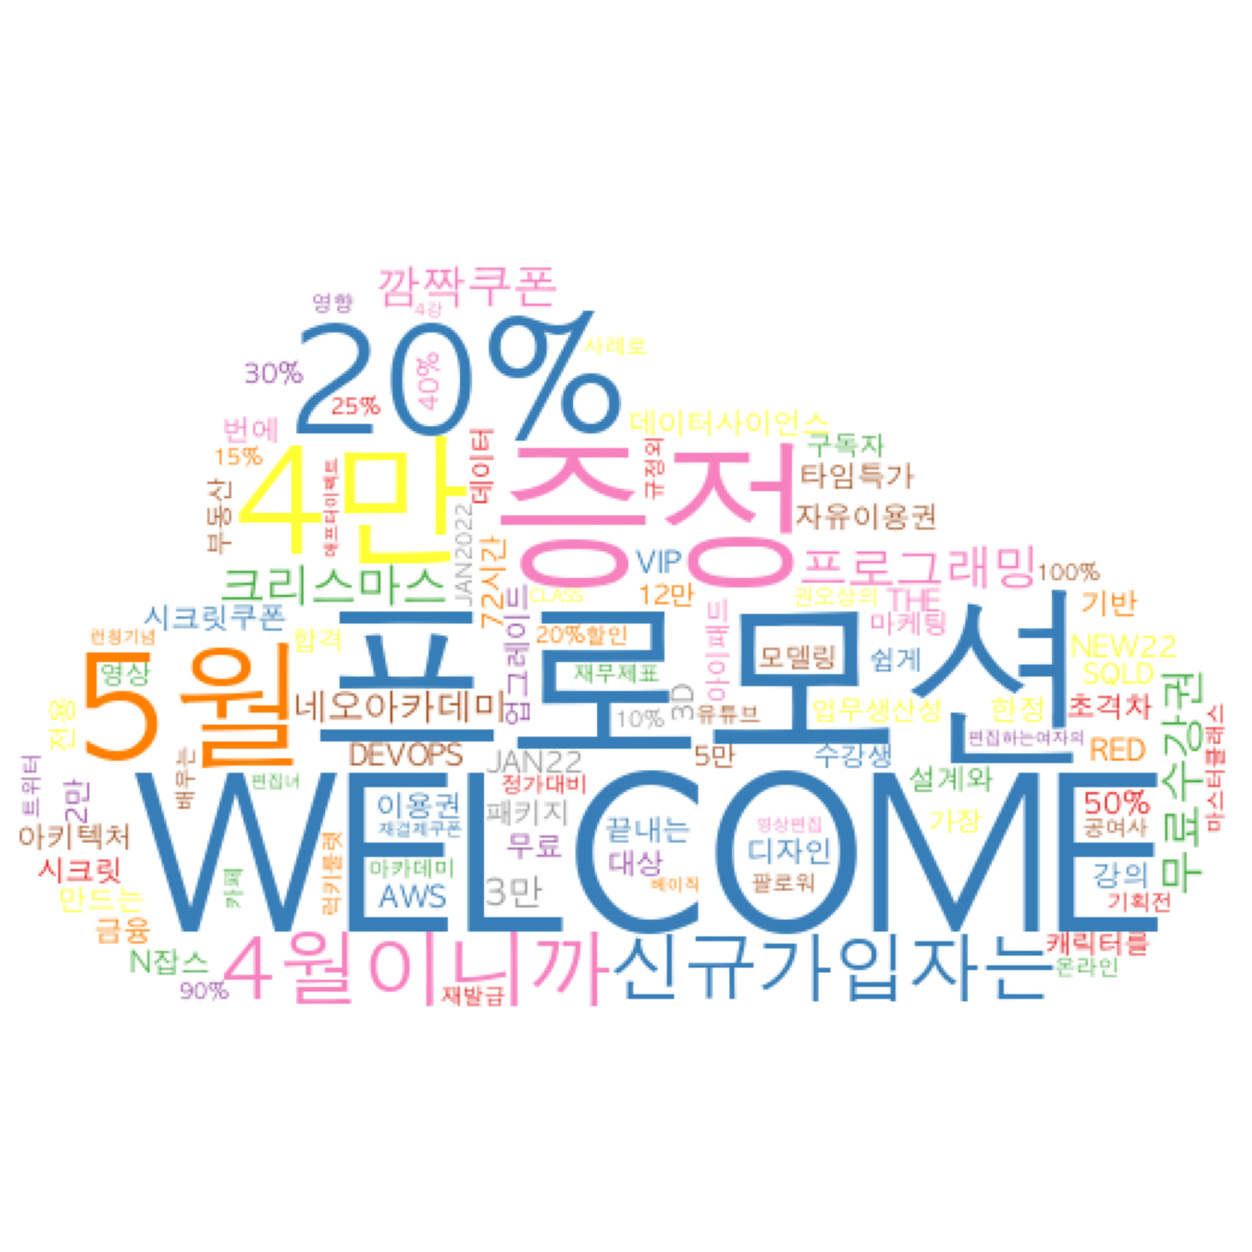

In [46]:
# word cloud 생성
mask = np.array(Image.open("./data/cloud.png"))
wordcloud = WordCloud(
    font_path="AppleGothic",
    relative_scaling=0.2,
    mask=mask,
    background_color="white",
    colormap="Set1",
).generate_from_frequencies(wordInfo)
plt.figure(figsize=(16, 16))
plt.imshow(wordcloud)
plt.axis("off")
plt.savefig("./wordcloud_naverNews(count).png")
plt.show()


-  *WELCOME, 프로모션, 증정, 4만, 5월 등이 눈에 뛰는 것*을 다시 확인
	- 아래 그래프는 색깔에 더해서 *쿠폰 이름도 같이 볼 수* 있게 하였음

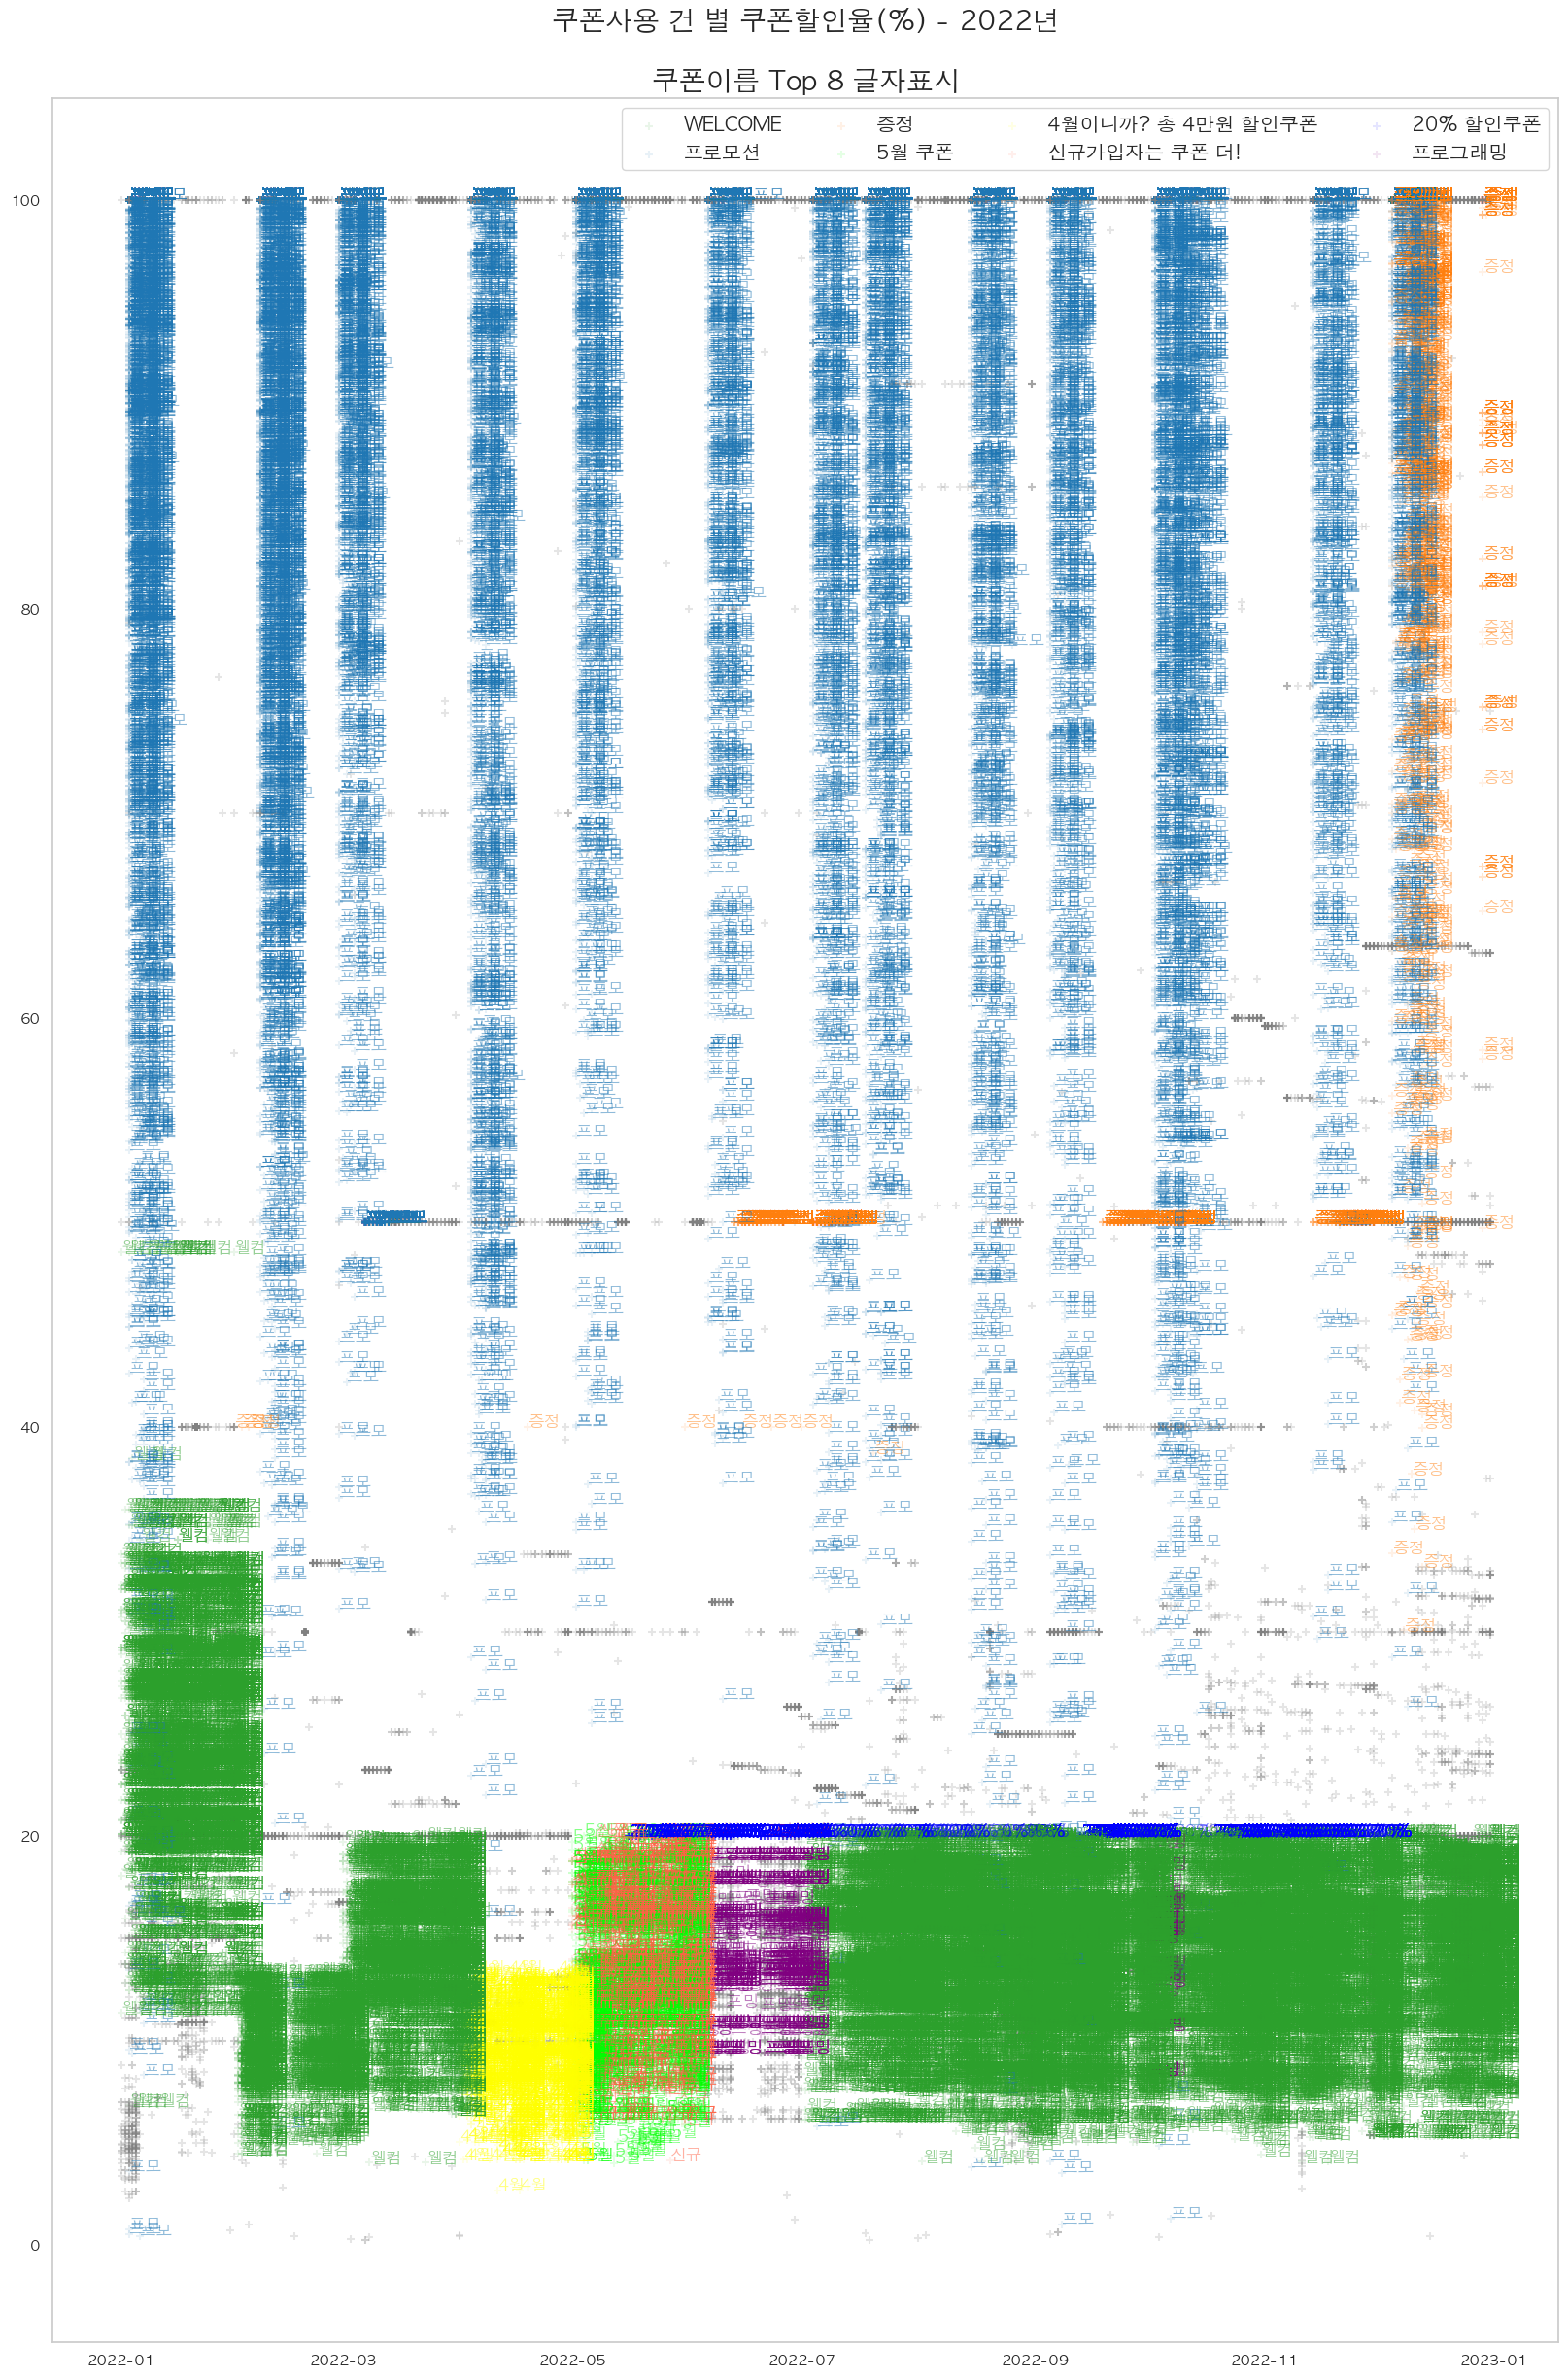

In [47]:
# scatter plot(with text) : year

# 할인율('할인금액조정'/'판매가격') 빈도수 22년
plt.figure(figsize=(20, 30))

# show_cp_tag 갯수 만큼 scatter 만들기
cp_tag_df = df[df["할인금액조정"] > 0][["p_date", "할인금액조정", "판매가격", "cp_tag"]]
for cp_tag in show_cp_tag.index:
    x = cp_tag_df[cp_tag_df["cp_tag"] == cp_tag]["p_date"]
    y = (
        cp_tag_df[cp_tag_df["cp_tag"] == cp_tag]["할인금액조정"]
        / cp_tag_df[cp_tag_df["cp_tag"] == cp_tag]["판매가격"]
        * 100
    )

    plt.scatter(
        x,
        y,
        marker="+",
        label=cp_tag,
        alpha=0.1,
        c=show_cp_tag.loc[cp_tag, "color"],
    )

# show_cp_tag 외 만들기
cp_tag_df = df[
    (df["할인금액조정"] > 0) & ((df["cp_tag"].isin(show_cp_tag.index)) == False)
][["p_date", "할인금액조정", "판매가격", "cp_tag"]]
x = cp_tag_df["p_date"]  # x축은 일자입니다. 20220101 ~ 20221231
y = cp_tag_df["할인금액조정"] / cp_tag_df["판매가격"] * 100  # y축은 할인율% 입니다. 0% ~ 100%

plt.scatter(x, y, marker="+", label="나머지", alpha=0.2, c="grey")

# text 덮어씌우기
x = df[df["할인금액조정"] > 0]["p_date"]  # x축은 일자입니다. 20220101 ~ 20221231
y = (
    df[df["할인금액조정"] > 0]["할인금액조정"] / df[df["할인금액조정"] > 0]["판매가격"] * 100
)  # y축은 할인율% 입니다. 0% ~ 100%
s = df[df["할인금액조정"] > 0]["cp_tag"]

for x_val, y_val, s_val in zip(
    x, y, s
):  # 결과에서 처럼 해당 포인트에 text를 넣고 싶다면, for문을 이용해야합니다.
    if (s_val in show_cp_tag.index) == True:
        plt.text(
            x=x_val,
            y=y_val,
            s=s_val,
            c=show_cp_tag.loc[s_val, "color"],
            alpha=0.5,
        )

# 출력
plt.title(
    "쿠폰사용 건 별 쿠폰할인율(%) - 2022년\n\n쿠폰이름 Top 8 글자표시",
    fontsize=20,
    fontweight="bold",
)
labels = [
    "WELCOME",
    "프로모션",
    "증정",
    "5월 쿠폰",
    "4월이니까? 총 4만원 할인쿠폰",
    "신규가입자는 쿠폰 더!",
    "20% 할인쿠폰",
    "프로그래밍",
]
plt.legend(labels=labels, loc="upper right", ncol=4, fontsize="large")
plt.grid()
plt.show()


-  5월 한달간의 쿠폰할인율 scatter그래프
	-  *월초에 프로모션이 강하게* 있고, 신규와 *5월, 등이 낮은 할인율에 고르게 분포*해서 
	- *신규 유입을 꾸준히 노린다*는 것을 알 수 있음

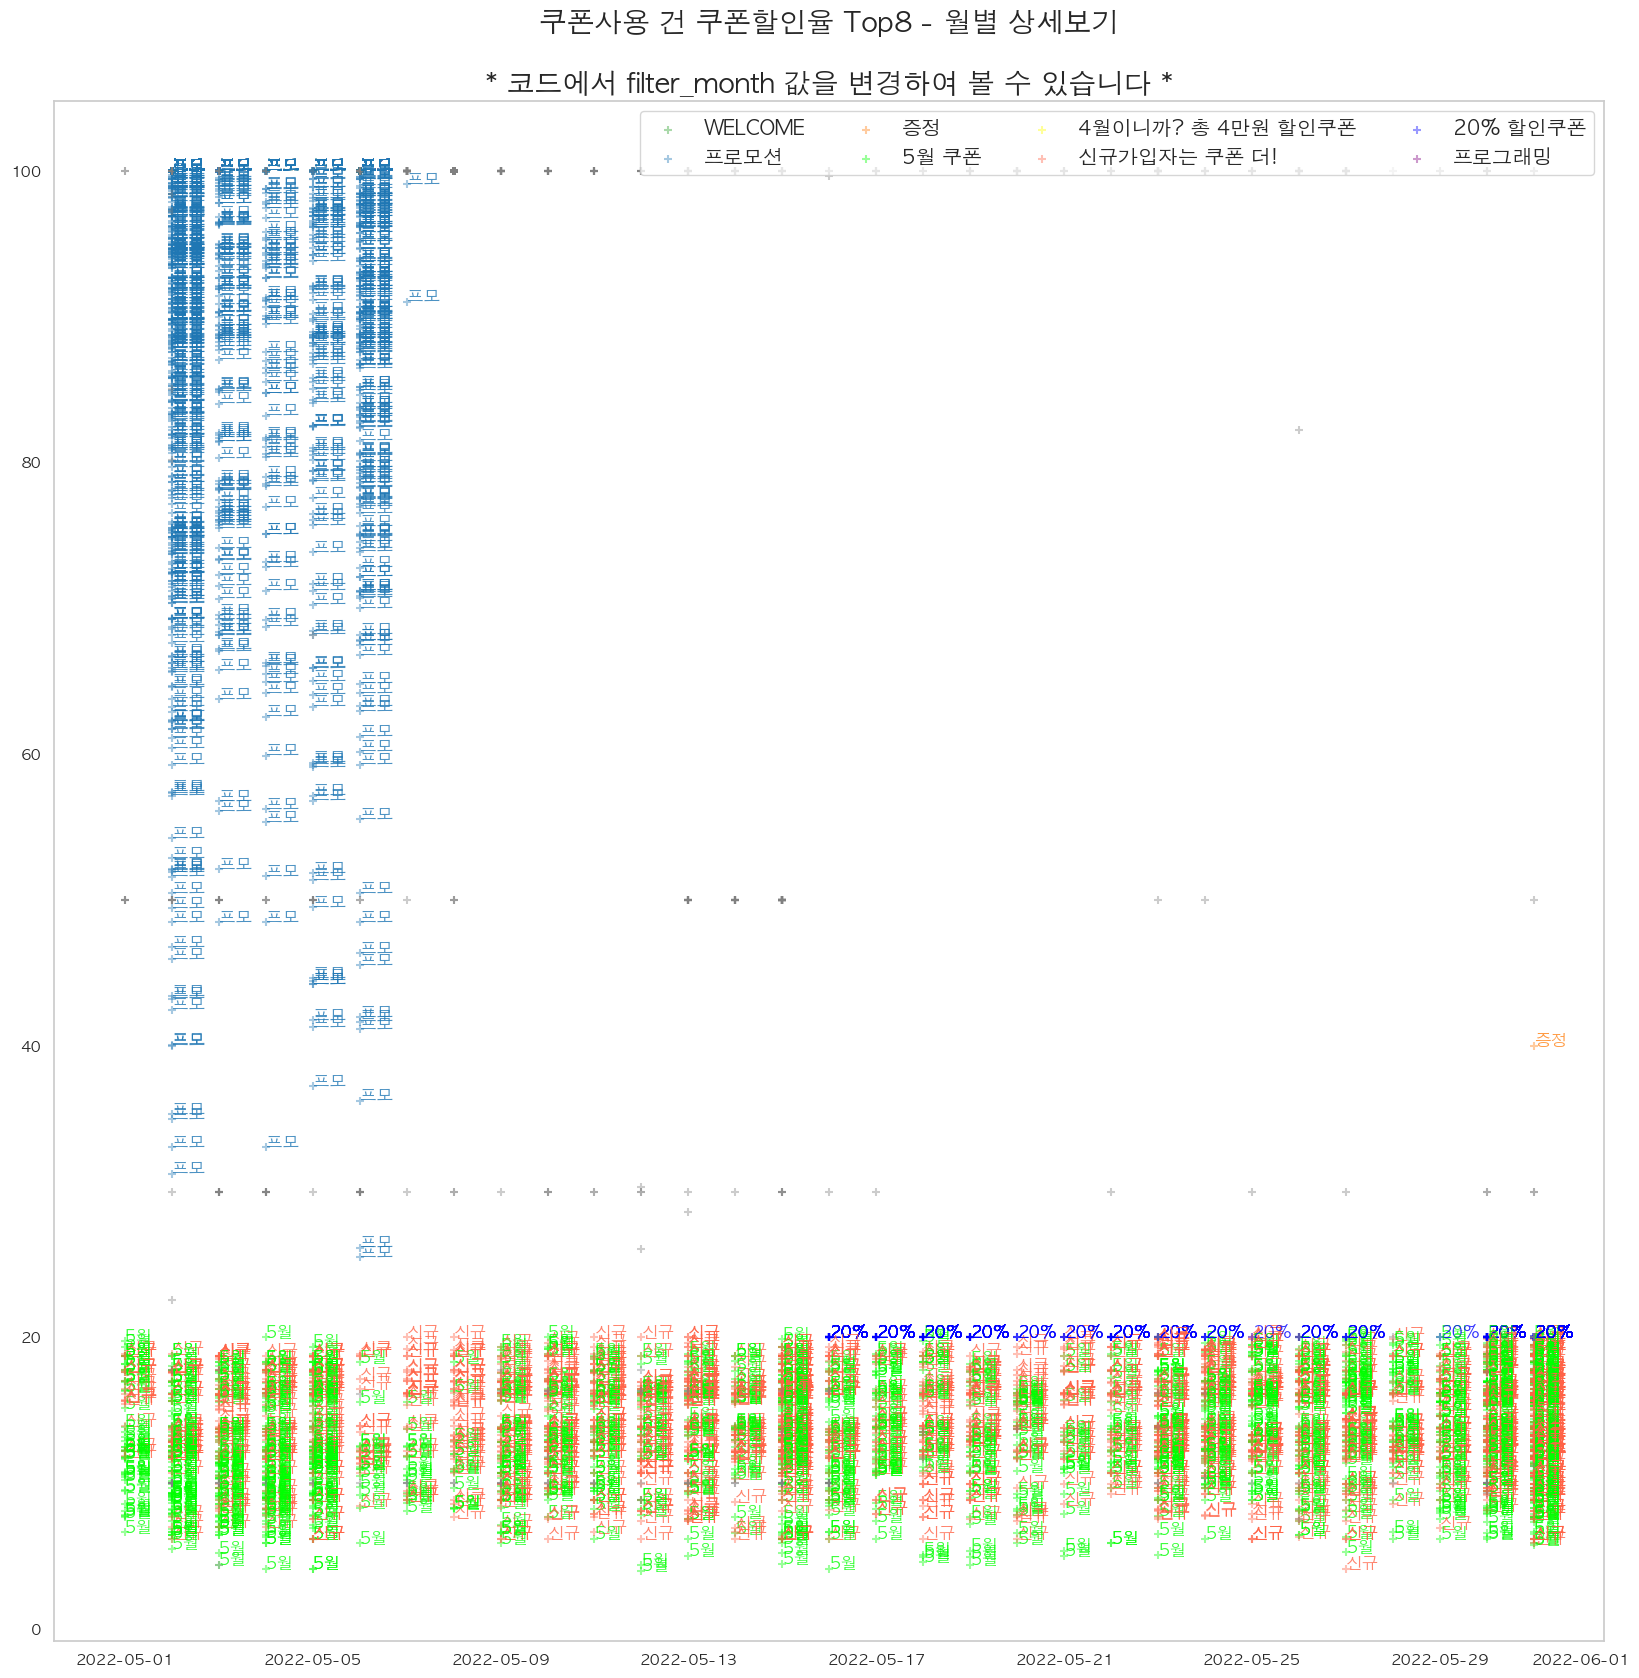

In [48]:
# scatter plot(with text) : month

filter_month = 5

plt.figure(figsize=(20, 20))  # filter_month 값을 변경하여 해당 월의 상세보기가 가능하다

# show_cp_tag 갯수 만큼 scatter 만들기
cp_tag_df = df[(df["할인금액조정"] > 0) & (df["p_date"].dt.month == filter_month)][
    ["p_date", "할인금액조정", "판매가격", "cp_tag"]
]
for cp_tag in show_cp_tag.index:
    x = cp_tag_df[cp_tag_df["cp_tag"] == cp_tag]["p_date"]
    y = (
        cp_tag_df[cp_tag_df["cp_tag"] == cp_tag]["할인금액조정"]
        / cp_tag_df[cp_tag_df["cp_tag"] == cp_tag]["판매가격"]
        * 100
    )

    plt.scatter(
        x,
        y,
        marker="+",
        label=cp_tag,
        alpha=0.4,
        c=show_cp_tag.loc[cp_tag, "color"],
    )

# show_cp_tag 외 만들기
cp_tag_df = df[
    (df["할인금액조정"] > 0)
    & ((df["cp_tag"].isin(show_cp_tag.index)) == False)
    & (df["p_date"].dt.month == filter_month)
][["p_date", "할인금액조정", "판매가격"]]
x = cp_tag_df["p_date"]  # x축은 일자입니다. 20220101 ~ 20221231
y = cp_tag_df["할인금액조정"] / cp_tag_df["판매가격"] * 100

plt.scatter(x, y, marker="+", label="나머지", alpha=0.4, c="grey")

# text 덮어씌우기
cp_tag_df = df[(df["할인금액조정"] > 0) & (df["p_date"].dt.month == filter_month)][
    ["p_date", "할인금액조정", "판매가격", "cp_tag"]
]
x = cp_tag_df["p_date"]  # x축은 일자입니다. 20220101 ~ 20221231
y = cp_tag_df["할인금액조정"] / cp_tag_df["판매가격"] * 100  # y축은 할인율% 입니다. 0% ~ 100%
s = cp_tag_df["cp_tag"]

for x_val, y_val, s_val in zip(
    x, y, s
):  # 결과에서 처럼 해당 포인트에 text를 넣고 싶다면, for문을 이용해야합니다.
    if (s_val in show_cp_tag.index) == True:
        plt.text(
            x=x_val,
            y=y_val,
            s=s_val,
            c=show_cp_tag.loc[s_val, "color"],
            alpha=0.8,
        )

# 출력
plt.title(
    "쿠폰사용 건 쿠폰할인율 Top8 - 월별 상세보기\n\n* 코드에서 filter_month 값을 변경하여 볼 수 있습니다 *",
    fontsize=20,
    fontweight="bold",
)
labels = [
    "WELCOME",
    "프로모션",
    "증정",
    "5월 쿠폰",
    "4월이니까? 총 4만원 할인쿠폰",
    "신규가입자는 쿠폰 더!",
    "20% 할인쿠폰",
    "프로그래밍",
]
plt.legend(labels=labels, loc="upper right", ncol=4, fontsize="large")
plt.grid()
plt.show()


[미국 노동청 자료](https://www.bls.gov/ooh/fastest-growing.htm)
| OCCUPATION                                    | GROWTH RATE, 2021-31 | 2021 MEDIAN PAY   |
| --------------------------------------------- | -------------------- | ----------------- |
| Data scientists                               | 36%                  | $100,910 per year |
| Athletes and sports competitors               | 36%                  | $77,300 per year  |
| Infomation security analysts                  | 35%                  | $102,600 per year |
| Statisticians                                 | 33%                  | $95,570 per year  |
| Umpires, referees, and other sports officials | 32%                  | $35,860 per year  |
| Web developers                                | 30%                  | $77,030 per year   

# **4. 프로젝트를 진행하며 느낀점**

- 최우성
	- 처음 프로젝트를 시작하였을땐 어떻게 진행해야 할지 감도 안왔지만 그래프를 그리다 보니 자연스럽게 진행 방향이 잡혔고, 그래서 시각화가 왜 중요한지 알 수 있었습니다. 그리고 잘못된 생각으로 해석하면 같은 자료를 두고도 다른 결론을 내릴 수 있음을 깨달았습니다. 조원 들과 함께 토론하며 잘못된 부분을 서로 찾아줘서 큰 도움이 되었고, 같은 주제로 다같이 토론 하며 진행하니 즐거웠습니다.
	- 처음에는 '이거 어떻게 해야하죠?' 라고 물으면 다들 '그러게요..?' 라고 했었는데 마지막에 가서는 '이거 필요하겠는 데요?' 라고 말하면 누군가가 척척 만들어서 오는걸 보고 다들 짧은기간에 많이 능숙해 졌다고 생각했습니다.
	- 저희팀은 쿠폰을 주제로 잡고 EDA를 진행하였는데 예상과 다른 결과들도 많이나와, 직감으로 '이렇지 않을까?' 와 실제로 데이터를 분석하는 것엔 차이가 크다는 것을 느꼈습니다.
- 조용준
	- 프로젝트 진행 이전에는 매출액의 문제점들을 월별로 잘 보여 줄 수 있을 것이라고 생각했는데, 생각보다 많이 다양한 이유로,, 쿠폰과 연관이 있거나 연관이 없는 허무한 결과가 종종 있어서 찾는 과정이 순탄치 않았습니다.
	- 프로젝트를 진행하면서, 하나의 서비스에는 많은 요인들이 존재한다는걸 알았습니다.  또한, 매일 팀원들에게 혹은 오늘 발표에서, 어떻게 설득을 효과적으로 할 수 있을까  라는 형식을 고민하고, 그래프를 그려보는 과정에서 많은 실력 향상이 있었습니다.
- 심성훈
	- refund가 있는 고객 데이터로 매출액을 정제하려고했는데, 이게 뭐라고 정성을 들였는지 모르겠네요. 최대한 빠르게 나머지전처리 요소와 그래프 주제에 맞게 준비하도록 하겠습니다.
	- 아 그리고 한가지 느낀점이 뭐였냐면, EDA 주피터 파일로 코드 테스트하고 열심히 코드짜고 그랬는데, 사실 의도한대로 테스트가 안되어도 어쨋든 컬럼하나 만들겠다고 혼자서 난리를 쳤죠. 근데 필요한 코드만 쫙 뽑아서 간단한 코드로 만들었더니, 구현 안되던 코드도 구현이 되버려가지고 (결측치 딕셔너리였나 할껍니다.)이제와서 구현이된거를 어떻게 또 짜야하는데 난감합니다. 허허..
- 신포숙
	-  머릿속 구상을 코드로 구현하는 것이 생각보다 오래 결려서 놀랐습니다. 
	-  다른 분들의 코드를 보면서 배울 점이 있어서 좋았습니다.
	-  팀으로 함께하는 경험을 할 수 있어서 좋았습니다. 의지가 많이 됐어요.
	-  시간이 흘러 시각화의 실력이 늘 수록 EDA에 대한 욕심이 생기는 것을 느꼈습니다. 하루 이틀 정도의 시간이 더 있었더라면 좀더 깊게 파고들어 유의미한 결과를 도출할 수 있었을텐데 아쉬웠습니다
- 정충원
	- 처음 데이터분석 프로젝트를 진행하기에 어떻게 문제 정의하고 풀어나가야하는지 어려움이 많았으나 팀원분들의 도움과 회의를 통해 실마리를 잡을수 있었던것 같다. 파이썬, 판다스와 이를 시각화 하는부분에서 미숙한 점이 많아 공부를 하며 기여하기에는 다소 촉박했고 타 조의 발표를 들으며 아 나도 이런부분을 좀더 도입해 볼껄 하는 아쉬움이 있었다. 더불어 문제 해결과정에서도 내가 설정한 문제를 확실히 근거있게 풀었는가에 대해서도 부족한 느낌이다.첫 데이터 분석 프로젝트에 좋은 팀원분들과 함께 나름의 결과물을 완성할수 있어서 좋았다.
- 박성빈
	- 제시된 목적성이나 방향성 없이, 있는 데이터에서 파생 가능한 모든 분석들을 제시하다보니 정신없고, 생각들을 한 곳에 모으는 과정이 힘들었습니다. 팀으로 EDA 프로젝트를 경험해볼 수 있어서 좋았습니다.

# *최종소감*

- 힘들었지만 조원들과 같이 해서 즐거웠습니다ㅎㅎ